# Summary: Deep Neural Networks for Acoustic Modeling in Speech Recognition

# https://www.cs.toronto.edu/~hinton/absps/DNN-2012-proof.pdf

## Abstract
This review article, authored jointly by researchers from the University of Toronto, Microsoft Research, Google, and IBM Research, surveys the use of deep neural networks (DNNs) as acoustic models in automatic speech recognition (ASR), replacing the long-dominant Gaussian mixture model (GMM) component of GMM-HMM systems. The paper explains the two-stage DNN training procedure (generative pretraining followed by discriminative fine-tuning), reviews phonetic classification/recognition results on TIMIT, and summarizes large-vocabulary continuous speech recognition (LVCSR) experiments across five industrial benchmark tasks, showing that DNN-HMM hybrid systems consistently and sometimes substantially outperform GMM-HMM systems.

## Problems
- **Statistical inefficiency of GMMs**: GMMs model probability distributions over acoustic feature vectors but are inefficient at representing data lying on or near a nonlinear manifold, requiring very large numbers of Gaussian components to approximate such structure.
- **Loss of information from feature engineering**: Standard preprocessing (MFCCs, PLPs) discards substantial waveform information deemed "irrelevant," discarding potentially useful structure and requiring decorrelated inputs for GMMs to work well.
- **Limitations of shallow neural networks**: Earlier neural network/HMM hybrids (two decades prior) used only a single hidden layer; hardware and training algorithms were inadequate for deep architectures, so gains over GMMs were insufficient to displace them.
- **Optimization difficulty of deep networks**: DNNs with many hidden layers are hard to optimize via naive gradient descent from random initialization near the origin, and gradients propagate with uneven magnitudes across layers, risking poor generalization and overfitting.

## Proposed Solutions
- **Deep Neural Network (DNN) acoustic models**: Feed-forward networks with more than one hidden layer, using logistic hidden units and a softmax output layer, trained to output posterior probabilities $$p(\text{HMMstate}|\text{AcousticInput})$$ directly, replacing GMM state-emission probability estimation.
- **Generative pretraining via Restricted Boltzmann Machines (RBMs) and Deep Belief Networks (DBNs)**: Each layer of feature detectors is learned one at a time using RBMs trained with Contrastive Divergence (CD), stacking them into a DBN, which is then used to initialize DNN weights ("DBN-DNN").
- **Discriminative fine-tuning**: After pretraining, the entire network (with an added softmax layer) is fine-tuned via backpropagation to minimize cross-entropy between predicted and target HMM state labels obtained from forced alignment with a baseline GMM-HMM system.
- **Sequence-level discriminative training (MMI)**: Maximum Mutual Information (MMI) training is applied on top of frame-level cross-entropy fine-tuning to directly optimize sequence-level objectives more correlated with word/phone error rate.
- **Context-dependent triphone state modeling**: Replacing monophone targets with tied triphone HMM states (thousands of output classes) to exploit richer label information and phonetic context.
- **Alternative pretraining and architecture variants**: Discriminative layer-wise pretraining, denoising/contractive autoencoders, sparse-code autoencoders, and convolutional DBN-DNNs (for temporal or frequency-domain invariance) are also discussed as alternatives to standard RBM pretraining.

## Purpose
The purpose of the paper is to consolidate and present the shared experimental findings of four leading speech research groups demonstrating that DNN-based acoustic models can outperform highly tuned GMM-HMM systems across a range of speech recognition tasks, to explain the underlying training methodology (pretraining plus fine-tuning), and to clarify why DNNs succeed where earlier shallow neural approaches failed, thereby establishing DNN-HMM hybrids as a superior alternative for acoustic modeling.

## Methodology
1. **DNN formulation**: Each hidden unit computes
$$y_j = \text{logistic}(x_j) = \frac{1}{1+e^{-x_j}}, \quad x_j = b_j + \sum_i y_i w_{ij}$$
and the output layer uses softmax:
$$p_j = \frac{\exp(x_j)}{\sum_k \exp(x_k)}$$
trained via backpropagation to minimize cross-entropy loss $$C = -\sum_j d_j \log p_j$$ using stochastic gradient descent with momentum:
$$\Delta w_{ij}(t) = \alpha \Delta w_{ij}(t-1) - \epsilon \frac{\partial C}{\partial w_{ij}(t)}$$

2. **RBM pretraining**: Each RBM layer has energy function
$$E(\mathbf{v}, \mathbf{h}) = -\sum_i a_i v_i - \sum_j b_j h_j - \sum_{i,j} v_i h_j w_{ij}$$
trained via Contrastive Divergence (CD$_1$), with conditional distributions $$p(h_j=1|\mathbf{v})$$ and $$p(v_i=1|\mathbf{h})$$ computed via logistic functions. For real-valued MFCC inputs, a Gaussian–Bernoulli RBM (GRBM) variant is used.

3. **Stacking into DBN-DNN**: RBMs are stacked layer-by-layer (each trained on the hidden-unit activations of the previous layer), combined into a DBN, then "unrolled" into a deterministic feed-forward DNN with an added softmax output layer for discriminative fine-tuning.

4. **HMM interfacing**: DNN posterior outputs are converted to scaled likelihoods by dividing by HMM state frequencies from forced alignment, for use in Viterbi decoding/forward-backward algorithms.

5. **Sequence discriminative training (MMI)**: Optimizes
$$p(l_{1:T}|v_{1:T}) = \frac{\exp\left(\sum_{t=1}^T \gamma_{ij}\phi_{ij}(l_{t-1},l_t) + \sum_{t=1}^T\sum_{d=1}^D \lambda_{ld} h_{td}\right)}{Z(h_{1:T})}$$
with gradients computed over transition parameters $$\gamma_{ij}$$, activation parameters $$\lambda_{kd}$$, and DNN weights $$w_{ij}$$.

6. **Experimental setup**: Evaluations conducted on the TIMIT phone recognition benchmark (192 sentence core test set) and five LVCSR tasks: Bing Voice Search (24h), Switchboard (309h), Google Voice Input (5,870h), YouTube (1,400h), and English Broadcast News (50h/430h), using varying architectures (4–8 hidden layers, 512–3,072 units/layer) and context-dependent triphone HMM states (761–17,552 classes) as targets.

## Results

| Task | Training Data (hours) | DNN-HMM WER (%) | GMM-HMM (same data) WER (%) | GMM-HMM (more data) WER (%) |
|---|---|---|---|---|
| Switchboard (Test Set 1) | 309 | 18.5 | 27.4 | 18.6 (2,000h) |
| Switchboard (Test Set 2) | 309 | 16.1 | 23.6 | 17.1 (2,000h) |
| English Broadcast News | 50 | 17.5 | 18.8 | — |
| Bing Voice Search (sentence error) | 24 | 30.4 | 36.2 | — |
| Google Voice Input | 5,870 | 12.3 | — | 16.0 (>>5,870h) |
| YouTube | 1,400 | 47.6 | 52.3 | — |

- On **TIMIT**, monophone DBN-DNNs (six layers) achieved 22.4% phone error rate (PER), improving to 20.7% with filter-bank features (eight layers) and 20.5% with mean-covariance RBM variants, outperforming prior methods including CD-HMM (27.3%), conditional random fields, and shallow recurrent networks.
- **Pretraining** consistently reduced overfitting and training time, though its absolute benefit diminished with larger labeled training sets and deeper networks (e.g., <1% WER reduction on Switchboard with 5+ layers).
- **Context-dependent triphone states** as targets were crucial and clearly superior to monophone targets.
- **Sequence-level MMI fine-tuning** provided further gains (e.g., ~5% relative improvement over frame-level training on TIMIT; error rate reduction from 12.3% to 12.2% on Google Voice Input).
- **Model combination** (DNN-HMM + GMM-HMM) yielded additional improvements (e.g., 11.8% WER on Google Voice Input).
- **Inference speed**: DNN-HMM recognition time for 1 second of speech was reduced from 1.6s to 210ms via 8-bit weight quantization and SIMD, or to 66ms using a GPU.
- **Bottleneck/tandem approaches** (using DNN-derived features as GMM inputs, e.g., AE-BN) also improved GMM-HMM systems, though less than direct DNN-HMM hybrids.

## Conclusions
- DNNs pretrained generatively (as DBNs) and discriminatively fine-tuned consistently outperform GMM-HMM systems across diverse ASR tasks, sometimes matching or exceeding GMM-HMMs trained on substantially more data.
- Most of the performance gain stems from DNNs' ability to exploit information across multiple neighboring acoustic frames and to model tied context-dependent (triphone) states directly, rather than from pretraining alone.
- Generative pretraining remains useful for reducing overfitting and fine-tuning time, particularly with limited labeled data, but careful initialization of random weights can achieve similar benefits with less computational effort.
- The principal disadvantage of DNNs relative to GMMs is the difficulty of parallelizing training across large compute clusters; GPU-based matrix parallelization mitigates but does not eliminate this bottleneck.
- The authors anticipate continued widening of the performance gap between DNN- and GMM-based acoustic models as network architectures, hidden unit types, and training algorithms are further refined.

# Mathematical and Statistical Content Extracted from the Paper

This paper's mathematics centers on how a Deep Neural Network (DNN) computes outputs, how it is trained (both greedily/generatively and discriminatively), and how it interfaces with Hidden Markov Models (HMMs) for speech recognition. Below is every equation with a plain-language explanation of its role.

## 1. Logistic Activation Function (Hidden Units)

$$y_j = \text{logistic}(x_j) = \frac{1}{1+e^{-x_j}}, \qquad x_j = b_j + \sum_i y_i w_{ij}$$

**Explanation**: Each hidden neuron $j$ sums up weighted signals $w_{ij}$ from the layer below plus a bias $b_j$, then squashes the result into a value between 0 and 1 using the sigmoid (logistic) function. This is the basic building block that lets a DNN transform raw acoustic features layer by layer into more abstract representations.

## 2. Softmax Function (Output Layer)

$$p_j = \frac{\exp(x_j)}{\sum_k \exp(x_k)}$$

**Explanation**: Converts the network's final layer of raw scores into a proper probability distribution over all possible output classes (HMM states), where $k$ indexes all classes. This ensures the DNN's output can be interpreted as $p(\text{HMM state} \mid \text{acoustic input})$.

## 3. Cross-Entropy Cost Function

$$C = -\sum_j d_j \log p_j$$

**Explanation**: Measures how far the network's predicted probabilities $p_j$ are from the true target labels $d_j$ (which are 0 or 1, indicating the correct class). Minimizing this cost via backpropagation is how the DNN learns to classify acoustic frames correctly.

## 4. Stochastic Gradient Descent with Momentum

$$\Delta w_{ij}(t) = \alpha \Delta w_{ij}(t-1) - \epsilon \frac{\partial C}{\partial w_{ij}(t)}$$

**Explanation**: The standard weight-update rule for training. $\epsilon$ is the learning rate (step size), and $\alpha$ (momentum coefficient, $0<\alpha<1$) smooths updates over time by blending in the previous update direction — this reduces oscillation and speeds convergence, especially in narrow "ravines" of the error surface.

## 5. Restricted Boltzmann Machine (RBM) Energy Function

$$E(\mathbf{v}, \mathbf{h}) = -\sum_{i \in \text{visible}} a_i v_i - \sum_{j \in \text{hidden}} b_j h_j - \sum_{i,j} v_i h_j w_{ij}$$

**Explanation**: An RBM is an undirected generative model with a layer of visible units $v$ (data) and hidden units $h$ (features), connected but with no within-layer connections. This "energy" quantifies how compatible a given configuration of visible and hidden states is — lower energy means higher probability. It underlies the unsupervised pretraining stage.

## 6. Joint and Marginal Probability from Energy (Boltzmann Distribution)

$$p(\mathbf{v}, \mathbf{h}; \mathbf{W}) = \frac{1}{Z}e^{-E(\mathbf{v},\mathbf{h};\mathbf{W})}, \qquad Z = \sum_{\mathbf{v}',\mathbf{h}'} e^{-E(\mathbf{v}',\mathbf{h}';\mathbf{W})}$$

$$p(\mathbf{v}) = \frac{1}{Z}\sum_{\mathbf{h}} e^{-E(\mathbf{v},\mathbf{h})}$$

**Explanation**: Converts energy into probability: configurations with lower energy are exponentially more probable. $Z$, the partition function, is a normalizing constant summing over all possible configurations (generally intractable to compute exactly, motivating approximate learning methods below).

## 7. Gradient of Log-Likelihood for RBM Training

$$\frac{1}{N}\sum_{n=1}^{N} \frac{\partial \log p(\mathbf{v}^n)}{\partial w_{ij}} = \langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{model}}$$

**Explanation**: The exact gradient for training an RBM by maximum likelihood is the difference between the correlation of visible/hidden units under the real training data ("data" expectation) and under the model's own generated samples ("model" expectation). This is simple in form but the model-expectation term is expensive to compute exactly.

## 8. Steepest Ascent Weight Update Rule

$$\Delta w_{ij} = \epsilon\left(\langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{model}}\right)$$

**Explanation**: The practical update rule derived from the gradient above — increase weights when data-driven correlations exceed model-driven correlations, and vice versa, scaled by learning rate $\epsilon$.

## 9. Conditional Distributions for Sampling (Gibbs Sampling)

$$p(h_j = 1 \mid \mathbf{v}) = \text{logistic}\left(b_j + \sum_i v_i w_{ij}\right)$$

$$p(v_i = 1 \mid \mathbf{h}) = \text{logistic}\left(a_i + \sum_j h_j w_{ij}\right)$$

**Explanation**: Because RBMs have no connections within a layer, it is easy to sample hidden units given visible units, and vice versa — each conditional distribution is just a logistic function. This bipartite structure is what makes RBMs tractable for layer-wise pretraining.

## 10. Contrastive Divergence (CD) Weight Update

$$\Delta w_{ij} = \epsilon\left(\langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{recon}}\right)$$

**Explanation**: A fast approximation to full maximum-likelihood learning. Instead of running Gibbs sampling to convergence to estimate $\langle v_i h_j \rangle_{\text{model}}$, CD uses a single "reconstruction" step (data → hidden → reconstructed visible → hidden again), making training far more computationally efficient while still working well in practice.

## 11. Gaussian–Bernoulli RBM (GRBM) Energy Function

$$E(\mathbf{v}, \mathbf{h}) = \sum_{i \in \text{vis}} \frac{(v_i - a_i)^2}{2\sigma_i^2} - \sum_{j \in \text{hid}} b_j h_j - \sum_{i,j} \frac{v_i}{\sigma_i} h_j w_{ij}$$

**Explanation**: A modification of the standard RBM to handle real-valued inputs (like MFCC acoustic coefficients) instead of binary data. Visible units are modeled as Gaussian-distributed with standard deviation $\sigma_i$, rather than binary Bernoulli variables, since raw acoustic features are continuous-valued.

## 12. GRBM Conditional Distributions

$$p(h_j \mid \mathbf{v}) = \text{logistic}\left(b_j + \sum_i \frac{v_i}{\sigma_i} w_{ij}\right)$$

$$p(h_j \mid \mathbf{h}) = \mathcal{N}\left(a_i + \sigma_i \sum_j h_j w_{ij}, \ \sigma_i^2\right)$$

**Explanation**: Analogous to the standard RBM conditionals, but the visible-unit reconstruction is now Gaussian-distributed ($\mathcal{N}$ denotes a normal distribution) rather than binary, reflecting the continuous nature of the acoustic input.

## 13. DBN Joint Probability via Layer Composition

$$p(\mathbf{v}; \mathbf{W}) = \sum_{\mathbf{h}} p(\mathbf{h}; \mathbf{W})\, p(\mathbf{v} \mid \mathbf{h}; \mathbf{W})$$

**Explanation**: Shows how stacking RBMs forms a Deep Belief Network (DBN): the hidden-unit distribution from one RBM becomes the "data" for the next, and this equation expresses the resulting layered generative model. Each additional stacked RBM is proven (via a variational bound argument) to only improve the model's fit to the data.

## 14. Maximum Mutual Information (MMI) Sequence Objective

$$p(l_{1:T} \mid v_{1:T}) = \frac{\exp\left(\sum_{t=1}^{T} \gamma_{ij}\phi_{ij}(l_{t-1}, l_t) + \sum_{t=1}^{T}\sum_{d=1}^{D} \lambda_{ld} h_{td}\right)}{Z(h_{1:T})}$$

**Explanation**: This is a sequence-level (rather than frame-level) training criterion. Instead of just classifying each frame independently, MMI optimizes the probability of the entire correct label sequence $l_{1:T}$ given the whole utterance. $\phi_{ij}$ are indicator "transition features" capturing HMM state transitions, and $h_{td}$ are DNN hidden-layer outputs acting as features into what is structurally a linear-chain conditional random field.

## 15. Gradients for MMI Fine-Tuning

$$\frac{\partial \log p(l_{1:T}^n \mid v_{1:T}^n)}{\partial \lambda_{kd}} = \sum_{t=1}^{T} \left(\delta(l_t^n = k) - p(l_t^n = k \mid v_{1:T}^n)\right) h_{td}^n$$

$$\frac{\partial \log p(l_{1:T}^n \mid v_{1:T}^n)}{\partial \gamma_{ij}} = \sum_{t=1}^{T}\left[\delta(l_{t-1}^n = i, l_t^n = j) - p(l_{t-1}^n = i, l_t^n = j \mid v_{1:T}^n)\right]$$

$$\frac{\partial \log p(l_{1:T}^n \mid v_{1:T}^n)}{\partial w_{ij}} = \sum_{t=1}^{T}\left[\lambda_{l_t^n d} - \sum_{k=1}^{K} p(l_t^n = k \mid v_{1:T}^n)\lambda_{kd}\right] h_{td}^n(1-h_{td}^n)x_{ti}^n$$

**Explanation**: These are the gradients needed to fine-tune the DNN's activation parameters $\lambda_{kd}$, HMM transition parameters $\gamma_{ij}$, and the DNN's internal weights $w_{ij}$ using MMI. Conceptually, each gradient compares the "observed" indicator (whether the correct label actually occurred, via the Kronecker delta $\delta$) against the "expected" value under the model's current predictions — the same error-driven learning principle as backpropagation, extended to full-sequence supervision.

## Summary Table of Mathematical Roles

| Equation Group | Role in Paper |
|---|---|
| Logistic / Softmax (1)-(2) | Define how DNN computes hidden and output probabilities |
| Cross-entropy (3)-(4) | Standard frame-level discriminative training objective and optimizer |
| RBM energy / probability (6)-(9) | Define unsupervised generative pretraining building block |
| Conditional sampling (10)-(11) | Enable tractable inference within an RBM |
| Contrastive Divergence (12) | Fast approximate RBM training algorithm actually used |
| GRBM (13)-(15) | Adapt RBM pretraining to continuous-valued acoustic features |
| DBN composition (16) | Formalizes stacking RBMs into a deep generative model |
| MMI objective and gradients (17)-(20) | Sequence-level discriminative fine-tuning, correlating training objective more closely with recognition error rate |

## Statistical Concepts Used (Non-Equation)

- **Word Error Rate (WER) / Phone Error Rate (PER)**: The primary evaluation statistics throughout, computed as the percentage of word or phone insertion, deletion, and substitution errors relative to a reference transcription.
- **Sentence Accuracy / Sentence Error Rate**: Alternative statistics reported for some tasks (e.g., Bing Voice Search), measuring whole-utterance correctness rather than per-word/phone correctness.
- **Held-out validation set performance**: Used as a statistical stopping criterion for training (both for annealing the learning rate and for early stopping to prevent overfitting).
- **Model combination**: Statistically combining outputs of multiple systems (e.g., DNN-HMM and GMM-HMM) — implicitly a form of ensemble averaging — to reduce error rates further than either system alone.

# Research Gaps, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | GMMs are statistically inefficient at modeling data lying on or near a nonlinear manifold in acoustic feature space. | GMM-HMM systems require a very large number of diagonal (or full-covariance) Gaussian components to approximate nonlinear structure in speech data, inflating model complexity without proportionate accuracy gains. | Replace GMM state-emission modeling with DNNs, which can represent nonlinear manifolds far more efficiently using distributed, layered feature representations. |
| 2 | Highly engineered, nonadaptive preprocessing (MFCCs, PLPs) discards potentially useful information in the raw waveform to satisfy GMM assumptions (e.g., decorrelated inputs). | GMMs cannot effectively model strongly correlated features like filter-bank coefficients, forcing reliance on lossy transformations that discard discriminative information. | Use DNNs, which do not require uncorrelated inputs and can be trained directly on filter-bank features, yielding lower phone error rates than MFCC-based models. |
| 3 | Early (pre-2000s) neural network/HMM hybrids used only a single hidden layer due to inadequate hardware and training algorithms. | Shallow networks did not provide sufficiently large accuracy gains over GMMs to displace them; neural networks were relegated to auxiliary roles (tandem/bottleneck feature extraction). | Introduce deep architectures (DNNs with multiple hidden layers, e.g., 5–8 layers) enabled by modern hardware (GPUs) and improved training algorithms, achieving substantial accuracy gains over single-layer networks and GMMs. |
| 4 | Deep networks are difficult to optimize: gradient descent from randomly initialized weights near the origin converges poorly, and gradients propagate with uneven magnitude across layers. | Without careful weight initialization, DNNs with many hidden layers and large parameter counts are prone to poor convergence and severe overfitting on limited labeled data. | Apply generative pretraining using stacked Restricted Boltzmann Machines (RBMs), forming a Deep Belief Network (DBN) that provides a well-conditioned starting point in weight-space for subsequent discriminative fine-tuning, reducing overfitting and easing optimization. |
| 5 | GMM-HMM systems produce state-emission probabilities using generative modeling assumptions ill-suited to discriminating between HMM states for classification accuracy. | Generative training (EM algorithm) optimizes data likelihood rather than the classification objective directly relevant to speech recognition accuracy (phone/word error rate). | Discriminatively fine-tune DNNs via backpropagation to directly predict target HMM states (from forced alignment), optimizing cross-entropy loss more closely aligned with recognition performance. |
| 6 | Frame-level discriminative training does not directly optimize sequence-level recognition accuracy (word/phone error rate). | Standard cross-entropy fine-tuning treats each frame independently, ignoring temporal dependencies between labels that affect the ultimate sequence-level error rate. | Apply sequence-level discriminative fine-tuning using Maximum Mutual Information (MMI) training, which optimizes the probability of the entire label sequence and better correlates with actual recognition error rate. |
| 7 | Monophone HMM state targets provide limited contextual information, restricting acoustic modeling accuracy in large-vocabulary tasks. | Prior GMM-HMM and early hybrid systems often relied on relatively coarse phonetic units, limiting the granularity of acoustic discrimination available to the model. | Replace monophone targets with tied context-dependent triphone HMM states (thousands of classes), supplying richer, more informative labels per frame and enabling more powerful triphone decoders. |
| 8 | DNNs use nearly all their parameters at every frame during inference, making them potentially much slower at recognition time than GMMs with comparable parameter counts. | State pruning and Gaussian selection methods (used to speed up GMM-HMM inference) are not applicable to DNNs, raising concerns about computational feasibility for real-time deployment. | Reduce inference time via 8-bit weight quantization combined with SIMD fixed-point computation on CPUs, or GPU acceleration, cutting per-second recognition time substantially without loss of accuracy. |
| 9 | It is unclear whether DNN-based acoustic modeling generalizes beyond small, controlled benchmarks (e.g., TIMIT) to real-world, large-vocabulary conditions. | Prior DNN-based phone recognition results were largely confined to TIMIT; performance improvements on small benchmarks do not necessarily transfer to large-vocabulary tasks with noisier, more varied data. | Validate the DNN-HMM approach across five diverse, large-scale LVCSR tasks (Switchboard, Bing Voice Search, Google Voice Input, YouTube, English Broadcast News) from three independent research groups, demonstrating consistent gains over GMM-HMM baselines. |
| 10 | Effective parallelization of DNN training across large compute clusters remains difficult, unlike GMM training via the EM algorithm. | GMM acoustic models can exploit cluster-based parallelism efficiently via EM, whereas DNN fine-tuning via backpropagation is harder to distribute at scale, creating a training-time bottleneck. | Employ GPU-based parallelization of matrix operations to accelerate DNN training (achieving one-to-two orders of magnitude speed-up), while acknowledging that fine-tuning remains a bottleneck requiring further research. |

In [27]:
# ============================================================================
# Educational PyTorch replication of Hinton et al. (2012), "Deep Neural
# Networks for Acoustic Modeling in Speech Recognition": a Gaussian-Bernoulli
# RBM + 2 Bernoulli RBMs pretrained greedily with CD-1, stacked into a DBN,
# converted to a deterministic DNN, then fine-tuned discriminatively.
# Task adaptation: 10-class Speech Commands word classification (softmax
# approximates p(word|audio), not tied HMM-state posteriors — no HMM
# decoder/forced alignment is implemented here).
# ============================================================================

# !pip -q install torchaudio scikit-learn

import os, random
from io import BytesIO

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchaudio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from IPython.display import display, Image as IPImage

# ---------------------------------------------------------------- setup ----
def enforce_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white", "savefig.facecolor": "white",
        "axes.facecolor": "white", "axes.edgecolor": "black",
        "axes.labelcolor": "black", "text.color": "black",
        "xtick.color": "black", "ytick.color": "black",
        "legend.facecolor": "white", "legend.edgecolor": "black",
        "grid.color": "#cccccc", "axes.titlecolor": "black",
        "axes.grid": True, "grid.alpha": 0.4,
    })
enforce_white_theme()

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Config flags
PRIMARY_MODE = "speech_command_classification"
FRAME_LEVEL_MODE = False          # no fabricated HMM-state labels
USE_RELU_FINE_TUNING = False      # keep sigmoid units (paper-faithful)
SAMPLE_GAUSSIAN_RECONSTRUCTIONS = False
RUN_WIDER_RANDOM_BASELINE = False
USE_AUDIO_AUGMENTATION = True

CONTEXT_FRAMES, N_MELS = 11, 40
INPUT_DIM = CONTEXT_FRAMES * N_MELS          # 440
SAMPLE_RATE, N_FFT, WIN_LENGTH, HOP_LENGTH, EPS = 16000, 400, 400, 160, 1e-6
N_TRAIN, N_VAL = 2000, 400
PRETRAIN_EPOCHS, CD_K = 5, 1
RBM_LEARNING_RATE, INITIAL_MOMENTUM, FINAL_MOMENTUM, RBM_WEIGHT_DECAY = 1e-3, 0.5, 0.9, 1e-4
BATCH_SIZE, FINE_TUNE_EPOCHS = 64, 5

class_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
N_CLASSES = len(class_names)

In [28]:
# ============================================================================
# DATASET LOADING — torchaudio SPEECHCOMMANDS (no HF loading script needed)
# ============================================================================
DATA_ROOT = "./speech_commands_data"
os.makedirs(DATA_ROOT, exist_ok=True)

train_pool = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_ROOT, download=True, subset="training")
val_pool = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_ROOT, download=True, subset="validation")

def build_index_by_class(pool, targets):
    # label = parent-folder basename of each waveform's file path
    out = {n: [] for n in targets}
    target_set = set(targets)
    for idx, file_path in enumerate(pool._walker):
        label = os.path.basename(os.path.dirname(file_path))
        if label in target_set:
            out[label].append(idx)
    return out

train_idx_by_class = build_index_by_class(train_pool, class_names)
val_idx_by_class = build_index_by_class(val_pool, class_names)
for name in class_names:
    assert train_idx_by_class[name] and val_idx_by_class[name], f"No examples found for '{name}'"

name_to_id = {n: i for i, n in enumerate(class_names)}
rng = np.random.RandomState(SEED)
train_per_class, val_per_class = N_TRAIN // N_CLASSES, N_VAL // N_CLASSES

def select_pairs(idx_by_class, per_class, cap):
    pairs = []
    for name in class_names:
        idxs = idx_by_class[name][:]
        rng.shuffle(idxs)
        pairs.extend([(i, name_to_id[name]) for i in idxs[:per_class]])
    rng.shuffle(pairs)
    return pairs[:cap]

train_selected = select_pairs(train_idx_by_class, train_per_class, N_TRAIN)
val_selected = select_pairs(val_idx_by_class, val_per_class, N_VAL)
print(f"Selected {len(train_selected)} training / {len(val_selected)} evaluation examples.")

Selected 2000 training / 400 evaluation examples.


In [29]:
# ============================================================================
# AUDIO PREPROCESSING — mono/resample/normalize -> log-Mel -> context stack
# ============================================================================
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH, n_mels=N_MELS
)

def preprocess_waveform(waveform_np, orig_sr):
    wav = torch.as_tensor(waveform_np, dtype=torch.float32)
    if wav.dim() == 2:
        wav = wav.mean(dim=0)
    if orig_sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, orig_sr, SAMPLE_RATE)
    peak = wav.abs().max()
    if peak > 1e-8:
        wav = wav / peak
    if wav.shape[0] > SAMPLE_RATE:
        wav = wav[:SAMPLE_RATE]
    elif wav.shape[0] < SAMPLE_RATE:
        wav = F.pad(wav, (0, SAMPLE_RATE - wav.shape[0]))
    return wav

def augment_waveform(wav):
    wav = torch.roll(wav, shifts=random.randint(-800, 800))
    return wav + torch.randn_like(wav) * 0.003

def compute_log_mel(wav):
    return torch.log(mel_transform(wav.unsqueeze(0)).squeeze(0) + EPS)

def context_stack(log_mel):
    # Divide the log-Mel matrix into CONTEXT_FRAMES temporal regions and
    # average each, approximating the paper's central-frame + neighbors
    # context window with one fixed-size vector per utterance.
    n_mels, T = log_mel.shape
    bounds = np.linspace(0, T, CONTEXT_FRAMES + 1).astype(int)
    regions = []
    for i in range(CONTEXT_FRAMES):
        lo, hi = bounds[i], min(max(bounds[i] + 1, bounds[i + 1]), T)
        seg = log_mel[:, lo:hi]
        regions.append(seg.mean(dim=1) if seg.shape[1] else log_mel[:, -1:].mean(dim=1))
    return torch.cat(regions, dim=0)  # (440,)

def extract_raw_feature(waveform_np, orig_sr, augment=False):
    wav = preprocess_waveform(waveform_np, orig_sr)
    if augment and USE_AUDIO_AUGMENTATION:
        wav = augment_waveform(wav)
    log_mel = compute_log_mel(wav)
    return context_stack(log_mel), wav, log_mel

In [30]:
# ============================================================================
# DATASET WRAPPER
# ============================================================================
class SpeechCommandsDataset(Dataset):
    def __init__(self, pool, selected_pairs, mean=None, std=None, augment=False):
        self.pool, self.selected_pairs = pool, selected_pairs
        self.mean, self.std, self.augment = mean, std, augment

    def __len__(self):
        return len(self.selected_pairs)

    def __getitem__(self, idx):
        pool_idx, label = self.selected_pairs[idx]
        waveform, sr, *_ = self.pool[pool_idx]
        feat, _, _ = extract_raw_feature(waveform.squeeze(0).numpy().astype(np.float32),
                                          sr, augment=self.augment)
        if self.mean is not None:
            feat = (feat - self.mean) / (self.std + 1e-8)
        return feat, label

raw_train_ds = SpeechCommandsDataset(train_pool, train_selected)
raw_val_ds = SpeechCommandsDataset(val_pool, val_selected)

train_feats_raw, train_labels = [], []
for i in range(len(raw_train_ds)):
    feat, label = raw_train_ds[i]
    train_feats_raw.append(feat); train_labels.append(label)

pool_idx0, _ = train_selected[0]
wav0, sr0, *_ = train_pool[pool_idx0]
_example_feat, example_wav, example_log_mel = extract_raw_feature(
    wav0.squeeze(0).numpy().astype(np.float32), sr0, augment=False)
example_sr = SAMPLE_RATE

train_feats_raw = torch.stack(train_feats_raw)
train_labels = torch.tensor(train_labels, dtype=torch.long)
FEATURE_MEAN, FEATURE_STD = train_feats_raw.mean(dim=0), train_feats_raw.std(dim=0)

val_feats_raw, val_labels = [], []
for i in range(len(raw_val_ds)):
    feat, label = raw_val_ds[i]
    val_feats_raw.append(feat); val_labels.append(label)
val_feats_raw = torch.stack(val_feats_raw)
val_labels = torch.tensor(val_labels, dtype=torch.long)

X_train = ((train_feats_raw - FEATURE_MEAN) / (FEATURE_STD + 1e-8)).to(DEVICE)
X_val = ((val_feats_raw - FEATURE_MEAN) / (FEATURE_STD + 1e-8)).to(DEVICE)
y_train, y_val = train_labels.to(DEVICE), val_labels.to(DEVICE)

# pin_memory=False: tensors already live on DEVICE, pinning only applies to CPU tensors
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0, pin_memory=False)

# ---------------------------------------------------------- sanity check ---
print("=" * 60, "\nDATA SANITY CHECK\n" + "=" * 60)
print(f"Train/Eval examples: {X_train.shape[0]}/{X_val.shape[0]}")
print(f"Waveform shape: {tuple(example_wav.shape)} @ {example_sr} Hz")
print(f"Log-Mel shape: {tuple(example_log_mel.shape)} | context feature: {INPUT_DIM}")
print(f"Input range: [{X_train.min():.3f}, {X_train.max():.3f}] | Device: {DEVICE}")
print(f"First 8 labels: {[class_names[i] for i in y_train[:8].tolist()]}")

assert torch.isfinite(example_wav).all()
assert example_wav.shape[0] == SAMPLE_RATE
assert torch.isfinite(X_train).all() and torch.isfinite(X_val).all()
assert abs(X_train.mean().item()) < 0.5
assert y_train.min() >= 0 and y_train.max() <= 9

DATA SANITY CHECK
Train/Eval examples: 2000/400
Waveform shape: (16000,) @ 16000 Hz
Log-Mel shape: (40, 101) | context feature: 440
Input range: [-3.149, 4.969] | Device: cuda
First 8 labels: ['right', 'down', 'stop', 'down', 'right', 'yes', 'right', 'off']


In [31]:
# ============================================================================
# RESTRICTED BOLTZMANN MACHINES + CD-1
# ============================================================================
# RBM1: Gaussian-Bernoulli (real-valued acoustic inputs, sigma fixed to 1
# since inputs are standardized). RBM2/3: Bernoulli-Bernoulli, trained on
# the deterministic hidden probabilities of the layer below (greedy
# layer-wise pretraining -> stacked Deep Belief Network). All training is
# unsupervised (no labels, no cross-entropy) and done manually with CD-1
# (no autograd/optimizers), matching the paper's classical recipe.

class GaussianBernoulliRBM:
    def __init__(self, n_vis, n_hid, device):
        self.W = torch.randn(n_vis, n_hid, device=device) * 0.01
        self.visible_bias = torch.zeros(n_vis, device=device)
        self.hidden_bias = torch.zeros(n_hid, device=device)
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_visible_bias = torch.zeros_like(self.visible_bias)
        self.velocity_hidden_bias = torch.zeros_like(self.hidden_bias)

    def hidden_prob(self, v):
        return torch.sigmoid(v @ self.W + self.hidden_bias)

    def visible_mean(self, h):
        return self.visible_bias + h @ self.W.t()

    def visible_sample(self, h):
        mean = self.visible_mean(h)
        return mean + torch.randn_like(mean) if SAMPLE_GAUSSIAN_RECONSTRUCTIONS else mean

    def compute_free_energy(self, v):
        quad = 0.5 * ((v - self.visible_bias) ** 2).sum(dim=1)
        return quad - F.softplus(v @ self.W + self.hidden_bias).sum(dim=1)

class BernoulliBernoulliRBM:
    def __init__(self, n_vis, n_hid, device):
        self.W = torch.randn(n_vis, n_hid, device=device) * 0.01
        self.visible_bias = torch.zeros(n_vis, device=device)
        self.hidden_bias = torch.zeros(n_hid, device=device)
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_visible_bias = torch.zeros_like(self.visible_bias)
        self.velocity_hidden_bias = torch.zeros_like(self.hidden_bias)

    def hidden_prob(self, v):
        return torch.sigmoid(v @ self.W + self.hidden_bias)

    def visible_prob(self, h):
        return torch.sigmoid(h @ self.W.t() + self.visible_bias)

    def compute_free_energy(self, v):
        vis_term = (v * self.visible_bias).sum(dim=1)
        return -vis_term - F.softplus(v @ self.W + self.hidden_bias).sum(dim=1)

def pseudo_likelihood_bernoulli(rbm, v):
    # Rough proxy only (Z is intractable) — flips one bit, compares free energies.
    with torch.no_grad():
        n = v.shape[1]
        flip = torch.randint(0, n, (v.shape[0],), device=v.device)
        v2 = v.clone()
        v2[torch.arange(v.shape[0]), flip] = 1 - v2[torch.arange(v.shape[0]), flip]
        return (n * torch.log(torch.sigmoid(rbm.compute_free_energy(v2)
                                             - rbm.compute_free_energy(v)) + 1e-10)).mean().item()

def cd1_step(rbm, v_data, is_gaussian, lr, momentum, wd):
    with torch.no_grad():
        bs = v_data.shape[0]
        pos_h_prob = rbm.hidden_prob(v_data)
        pos_h_sample = torch.bernoulli(pos_h_prob)
        v_recon = rbm.visible_sample(pos_h_sample) if is_gaussian else rbm.visible_prob(pos_h_sample)
        neg_h_prob = rbm.hidden_prob(v_recon)

        pos_assoc = v_data.t() @ pos_h_prob / bs
        neg_assoc = v_recon.t() @ neg_h_prob / bs
        w_dir = pos_assoc - neg_assoc
        vb_dir = (v_data - v_recon).mean(dim=0)
        hb_dir = (pos_h_prob - neg_h_prob).mean(dim=0)

        rbm.velocity_W = momentum * rbm.velocity_W + lr * (w_dir - wd * rbm.W)
        rbm.velocity_visible_bias = momentum * rbm.velocity_visible_bias + lr * vb_dir
        rbm.velocity_hidden_bias = momentum * rbm.velocity_hidden_bias + lr * hb_dir
        rbm.W += rbm.velocity_W
        rbm.visible_bias += rbm.velocity_visible_bias
        rbm.hidden_bias += rbm.velocity_hidden_bias

        err = v_data - v_recon
        return {
            "mse": (err ** 2).mean().item(), "mae": err.abs().mean().item(),
            "pos_assoc_mag": pos_assoc.abs().mean().item(), "neg_assoc_mag": neg_assoc.abs().mean().item(),
            "assoc_contrast": (pos_assoc - neg_assoc).abs().mean().item(),
            "weight_update_norm": rbm.velocity_W.norm().item(),
            "visible_bias_update_norm": rbm.velocity_visible_bias.norm().item(),
            "hidden_bias_update_norm": rbm.velocity_hidden_bias.norm().item(),
            "mean_hidden_activation": pos_h_prob.mean().item(), "std_hidden_activation": pos_h_prob.std().item(),
            "hidden_sat_low": (pos_h_prob < 0.05).float().mean().item(),
            "hidden_sat_high": (pos_h_prob > 0.95).float().mean().item(), "weight_norm": rbm.W.norm().item(),
        }

def evaluate_rbm(rbm, v, is_gaussian):
    with torch.no_grad():
        h_prob = rbm.hidden_prob(v)
        v_recon = rbm.visible_mean(h_prob) if is_gaussian else rbm.visible_prob(h_prob)
        err = v - v_recon
        return (err ** 2).mean().item(), err.abs().mean().item(), v_recon, h_prob

def train_rbm(rbm, train_data, val_data, is_gaussian, name):
    keys = ["train_mse", "val_mse", "train_mae", "val_mae", "pos_assoc_mag", "neg_assoc_mag",
            "assoc_contrast", "weight_update_norm", "visible_bias_update_norm",
            "hidden_bias_update_norm", "mean_hidden_activation", "std_hidden_activation",
            "hidden_sat_low", "hidden_sat_high", "weight_norm", "pseudo_likelihood", "recon_displacement"]
    history = {k: [] for k in keys}
    n = train_data.shape[0]
    for epoch in range(PRETRAIN_EPOCHS):
        momentum = INITIAL_MOMENTUM if epoch < 2 else FINAL_MOMENTUM
        perm = torch.randperm(n, device=train_data.device)
        batches = [cd1_step(rbm, train_data[perm[s:s + BATCH_SIZE]], is_gaussian,
                             RBM_LEARNING_RATE, momentum, RBM_WEIGHT_DECAY)
                   for s in range(0, n, BATCH_SIZE)]
        avg = {k: float(np.mean([b[k] for b in batches])) for k in batches[0]}
        val_mse, val_mae, _, _ = evaluate_rbm(rbm, val_data, is_gaussian)
        pl = pseudo_likelihood_bernoulli(rbm, train_data[:min(256, n)]) if not is_gaussian else float("nan")

        history["train_mse"].append(avg["mse"]); history["val_mse"].append(val_mse)
        history["train_mae"].append(avg["mae"]); history["val_mae"].append(val_mae)
        for k in ["pos_assoc_mag", "neg_assoc_mag", "assoc_contrast", "weight_update_norm",
                  "visible_bias_update_norm", "hidden_bias_update_norm", "mean_hidden_activation",
                  "std_hidden_activation", "hidden_sat_low", "hidden_sat_high", "weight_norm"]:
            history[k].append(avg[k])
        history["pseudo_likelihood"].append(pl)
        history["recon_displacement"].append(avg["mse"] ** 0.5)

        print(f"[{name}] epoch {epoch+1}/{PRETRAIN_EPOCHS} train_mse={avg['mse']:.4f} "
              f"val_mse={val_mse:.4f} assoc_contrast={avg['assoc_contrast']:.4f} momentum={momentum}")
    return history

print("\n" + "=" * 60, "\nSTAGE 1: GREEDY GENERATIVE PRETRAINING\n" + "=" * 60)
rbm1 = GaussianBernoulliRBM(INPUT_DIM, 256, DEVICE)
rbm1_metrics = train_rbm(rbm1, X_train, X_val, True, "RBM1-Gaussian")
with torch.no_grad():
    H1_train, H1_val = rbm1.hidden_prob(X_train).detach(), rbm1.hidden_prob(X_val).detach()

rbm2 = BernoulliBernoulliRBM(256, 256, DEVICE)
rbm2_metrics = train_rbm(rbm2, H1_train, H1_val, False, "RBM2-Bernoulli")
with torch.no_grad():
    H2_train, H2_val = rbm2.hidden_prob(H1_train).detach(), rbm2.hidden_prob(H1_val).detach()

rbm3 = BernoulliBernoulliRBM(256, 128, DEVICE)
rbm3_metrics = train_rbm(rbm3, H2_train, H2_val, False, "RBM3-Bernoulli")
rbm_metrics_all = {1: rbm1_metrics, 2: rbm2_metrics, 3: rbm3_metrics}

with torch.no_grad():
    _, _, X_train_recon, _ = evaluate_rbm(rbm1, X_train, True)
    recon_err_matrix = ((X_train - X_train_recon) ** 2).mean(dim=0).view(CONTEXT_FRAMES, N_MELS).cpu().numpy()
    per_mel_mse = recon_err_matrix.mean(axis=0)


STAGE 1: GREEDY GENERATIVE PRETRAINING
[RBM1-Gaussian] epoch 1/5 train_mse=0.9559 val_mse=0.8469 assoc_contrast=0.0670 momentum=0.5
[RBM1-Gaussian] epoch 2/5 train_mse=0.6923 val_mse=0.5569 assoc_contrast=0.0864 momentum=0.5
[RBM1-Gaussian] epoch 3/5 train_mse=0.4627 val_mse=0.3911 assoc_contrast=0.0550 momentum=0.9
[RBM1-Gaussian] epoch 4/5 train_mse=0.3720 val_mse=0.3459 assoc_contrast=0.0450 momentum=0.9
[RBM1-Gaussian] epoch 5/5 train_mse=0.3290 val_mse=0.3006 assoc_contrast=0.0418 momentum=0.9
[RBM2-Bernoulli] epoch 1/5 train_mse=0.1443 val_mse=0.1399 assoc_contrast=0.0224 momentum=0.5
[RBM2-Bernoulli] epoch 2/5 train_mse=0.1433 val_mse=0.1396 assoc_contrast=0.0179 momentum=0.5
[RBM2-Bernoulli] epoch 3/5 train_mse=0.1426 val_mse=0.1368 assoc_contrast=0.0207 momentum=0.9
[RBM2-Bernoulli] epoch 4/5 train_mse=0.1352 val_mse=0.1223 assoc_contrast=0.0241 momentum=0.9
[RBM2-Bernoulli] epoch 5/5 train_mse=0.1061 val_mse=0.0834 assoc_contrast=0.0290 momentum=0.9
[RBM3-Bernoulli] epoch 1/

In [32]:
# ============================================================================
# DNN ARCHITECTURE + RBM -> DNN CONVERSION
# ============================================================================
class DBNDNN(nn.Module):
    """440 -> 256 -> 256 -> 128 -> 10, sigmoid hidden units, logits out
    (softmax applied outside forward() so CrossEntropyLoss gets raw logits)."""
    def __init__(self, input_dim=INPUT_DIM, h1=256, h2=256, h3=128, n_classes=N_CLASSES, use_relu=False):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, h1)
        self.layer2 = nn.Linear(h1, h2)
        self.layer3 = nn.Linear(h2, h3)
        self.output = nn.Linear(h3, n_classes)
        self.act = torch.relu if use_relu else torch.sigmoid

    def forward(self, x):
        a1 = self.act(self.layer1(x))
        a2 = self.act(self.layer2(a1))
        a3 = self.act(self.layer3(a2))
        return self.output(a3), a1, a2, a3

    def predict_proba(self, x):
        logits, *_ = self.forward(x)
        return F.softmax(logits, dim=1)

    def extract_features(self, x):
        _, a1, a2, a3 = self.forward(x)
        return a1, a2, a3

print("\n" + "=" * 60, "\nSTAGE 1b: RBM STACK -> DETERMINISTIC DBN-DNN\n" + "=" * 60)
pretrained_dnn = DBNDNN(use_relu=USE_RELU_FINE_TUNING).to(DEVICE)
with torch.no_grad():
    pretrained_dnn.layer1.weight.copy_(rbm1.W.t()); pretrained_dnn.layer1.bias.copy_(rbm1.hidden_bias)
    pretrained_dnn.layer2.weight.copy_(rbm2.W.t()); pretrained_dnn.layer2.bias.copy_(rbm2.hidden_bias)
    pretrained_dnn.layer3.weight.copy_(rbm3.W.t()); pretrained_dnn.layer3.bias.copy_(rbm3.hidden_bias)
    # output layer stays randomly initialized

# independence check: DNN params are copies, not references
before = rbm1.W[0, 0].item()
with torch.no_grad():
    pretrained_dnn.layer1.weight[0, 0] += 999.0
assert rbm1.W[0, 0].item() == before, "DNN params must be independent of RBM params!"
with torch.no_grad():
    pretrained_dnn.layer1.weight[0, 0] -= 999.0
print("Independence check passed.")

random_dnn = DBNDNN(use_relu=USE_RELU_FINE_TUNING).to(DEVICE)
if RUN_WIDER_RANDOM_BASELINE:
    wider_random_dnn = DBNDNN(h1=512, h2=512, h3=256, use_relu=USE_RELU_FINE_TUNING).to(DEVICE)


STAGE 1b: RBM STACK -> DETERMINISTIC DBN-DNN
Independence check passed.


In [33]:
# ============================================================================
# SUPERVISED DISCRIMINATIVE FINE-TUNING (labels + cross-entropy + backprop)
# ============================================================================
def compute_calibration(probs, labels, n_bins=10):
    conf, preds = probs.max(dim=1)
    correct = (preds == labels).float()
    edges = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    ece = torch.tensor(0.0, device=probs.device)
    for i in range(n_bins):
        mask = (conf > edges[i]) & (conf <= edges[i + 1])
        if mask.sum() > 0:
            ece += mask.float().mean() * (correct[mask].mean() - conf[mask].mean()).abs()
    return ece.item()

def run_epoch(model, loader, optimizer=None, n_classes=N_CLASSES):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = total_correct = total_n = 0
    per_class_correct = np.zeros(n_classes); per_class_total = np.zeros(n_classes)
    grad_norms = {"layer1": [], "layer2": [], "layer3": [], "output": []}
    act_means = {"h1": [], "h2": [], "h3": []}; act_sat = {"h1": [], "h2": [], "h3": []}
    all_probs, all_labels = [], []

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for xb, yb in loader:
            if is_train:
                optimizer.zero_grad()
            logits, a1, a2, a3 = model(xb)
            loss = F.cross_entropy(logits, yb)
            if is_train:
                loss.backward()
                for name, layer in [("layer1", model.layer1), ("layer2", model.layer2),
                                     ("layer3", model.layer3), ("output", model.output)]:
                    if layer.weight.grad is not None:
                        grad_norms[name].append(layer.weight.grad.norm().item())
                optimizer.step()

            probs = F.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            total_loss += loss.item() * xb.shape[0]
            total_correct += (preds == yb).sum().item()
            total_n += xb.shape[0]
            for c in range(n_classes):
                mask = (yb == c)
                per_class_total[c] += mask.sum().item()
                per_class_correct[c] += (preds[mask] == c).sum().item()
            for name, a in zip(["h1", "h2", "h3"], [a1, a2, a3]):
                act_means[name].append(a.mean().item())
                act_sat[name].append(((a < 0.05) | (a > 0.95)).float().mean().item())
            all_probs.append(probs.detach()); all_labels.append(yb.detach())

    all_probs, all_labels = torch.cat(all_probs), torch.cat(all_labels)
    preds_all = all_probs.argmax(dim=1)
    conf_all, _ = all_probs.max(dim=1)
    correct_mask = preds_all == all_labels
    mean_conf_c = conf_all[correct_mask].mean().item() if correct_mask.any() else float("nan")
    mean_conf_i = conf_all[~correct_mask].mean().item() if (~correct_mask).any() else float("nan")
    entropy = -(all_probs * torch.log(all_probs + 1e-10)).sum(dim=1).mean().item()

    return {
        "loss": total_loss / total_n, "accuracy": total_correct / total_n,
        "per_class_accuracy": np.divide(per_class_correct, per_class_total,
                                         out=np.zeros_like(per_class_correct), where=per_class_total > 0),
        "grad_norms": {k: (float(np.mean(v)) if v else 0.0) for k, v in grad_norms.items()},
        "act_means": {k: float(np.mean(v)) for k, v in act_means.items()},
        "act_sat": {k: float(np.mean(v)) for k, v in act_sat.items()},
        "mean_conf_correct": mean_conf_c, "mean_conf_incorrect": mean_conf_i,
        "entropy": entropy, "ece": compute_calibration(all_probs, all_labels),
        "probs": all_probs.cpu().numpy(), "labels": all_labels.cpu().numpy(), "preds": preds_all.cpu().numpy(),
    }

def fine_tune(model, name):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    history = {"train": [], "val": []}
    for epoch in range(FINE_TUNE_EPOCHS):
        train_stats = run_epoch(model, train_loader, optimizer)
        val_stats = run_epoch(model, val_loader, optimizer=None)
        history["train"].append(train_stats); history["val"].append(val_stats)
        print(f"[{name}] epoch {epoch+1}/{FINE_TUNE_EPOCHS} train_loss={train_stats['loss']:.4f} "
              f"train_acc={train_stats['accuracy']*100:.1f}% val_loss={val_stats['loss']:.4f} "
              f"val_acc={val_stats['accuracy']*100:.1f}%")
    return history

print("\n" + "=" * 60, "\nSTAGE 2: DISCRIMINATIVE FINE-TUNING\n" + "=" * 60)
pretrained_history = fine_tune(pretrained_dnn, "Pretrained-DBN-DNN")
print("\n" + "=" * 60, "\nBASELINE: RANDOM-INIT DNN\n" + "=" * 60)
random_history = fine_tune(random_dnn, "Random-Init-DNN")


STAGE 2: DISCRIMINATIVE FINE-TUNING
[Pretrained-DBN-DNN] epoch 1/5 train_loss=2.3163 train_acc=9.2% val_loss=2.3078 val_acc=9.8%
[Pretrained-DBN-DNN] epoch 2/5 train_loss=2.3103 train_acc=9.6% val_loss=2.3164 val_acc=9.2%
[Pretrained-DBN-DNN] epoch 3/5 train_loss=2.3069 train_acc=10.2% val_loss=2.3130 val_acc=10.0%
[Pretrained-DBN-DNN] epoch 4/5 train_loss=2.3089 train_acc=11.2% val_loss=2.3100 val_acc=7.8%
[Pretrained-DBN-DNN] epoch 5/5 train_loss=2.3067 train_acc=10.7% val_loss=2.3074 val_acc=9.8%

BASELINE: RANDOM-INIT DNN
[Random-Init-DNN] epoch 1/5 train_loss=2.3161 train_acc=10.5% val_loss=2.3152 val_acc=10.0%
[Random-Init-DNN] epoch 2/5 train_loss=2.3211 train_acc=9.7% val_loss=2.3141 val_acc=10.0%
[Random-Init-DNN] epoch 3/5 train_loss=2.3158 train_acc=9.6% val_loss=2.3099 val_acc=10.0%
[Random-Init-DNN] epoch 4/5 train_loss=2.3157 train_acc=9.2% val_loss=2.3068 val_acc=10.0%
[Random-Init-DNN] epoch 5/5 train_loss=2.3158 train_acc=9.3% val_loss=2.3096 val_acc=10.0%


In [34]:
# ============================================================================
# PREDICTION PIPELINE + DNN->HMM POSTERIOR-TO-LIKELIHOOD (educational only)
# ============================================================================
def predict_audio(waveforms_np_list, sample_rates, model_name="pretrained"):
    model = pretrained_dnn if model_name == "pretrained" else random_dnn
    model.eval()
    feats = []
    for wav_np, sr in zip(waveforms_np_list, sample_rates):
        feat, _, _ = extract_raw_feature(wav_np, sr, augment=False)
        feats.append((feat - FEATURE_MEAN) / (FEATURE_STD + 1e-8))
    feats = torch.stack(feats).to(DEVICE)
    with torch.no_grad():
        logits, a1, a2, a3 = model(feats)
        probs = F.softmax(logits, dim=1)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)
        top3_vals, top3_idx = probs.topk(3, dim=1)
        preds = probs.argmax(dim=1)
    return {
        "features": feats.cpu(), "h1": a1.cpu(), "h2": a2.cpu(), "h3": a3.cpu(),
        "logits": logits.cpu(), "probs": probs.cpu(), "pred_labels": preds.cpu(),
        "pred_names": [class_names[i] for i in preds.cpu().tolist()],
        "confidence": probs.max(dim=1).values.cpu(), "entropy": entropy.cpu(),
        "top3": [(top3_idx[i].tolist(), top3_vals[i].tolist()) for i in range(len(preds))],
    }

def posterior_to_scaled_likelihood(posterior_probabilities, class_priors, epsilon=1e-8):
    # DNN outputs p(class|input); an HMM decoder needs p(input|state) instead.
    # Bayes' rule: log p(input|state) ~ log posterior - log prior. Illustrative
    # only -- no HMM decoder or tied HMM-state labels exist in this notebook.
    return torch.log(posterior_probabilities + epsilon) - torch.log(class_priors + epsilon)

class_priors = torch.bincount(y_train.cpu(), minlength=N_CLASSES).float()
class_priors /= class_priors.sum()

In [35]:
# ============================================================================
# ACOUSTIC FEATURE ANALYSIS
# ============================================================================
with torch.no_grad():
    final_pretrained_val = run_epoch(pretrained_dnn, val_loader, optimizer=None)
    final_random_val = run_epoch(random_dnn, val_loader, optimizer=None)
    _, h1_p, h2_p, h3_p = pretrained_dnn(X_val)
    _, h1_r, h2_r, h3_r = random_dnn(X_val)

X_val_np, y_val_np = X_val.cpu().numpy(), y_val.cpu().numpy()
h3_pretrained_np, h3_random_np = h3_p.cpu().numpy(), h3_r.cpu().numpy()

pca_raw = PCA(n_components=2).fit_transform(X_val_np)
pca_pretrained = PCA(n_components=2).fit_transform(h3_pretrained_np)
pca_random = PCA(n_components=2).fit_transform(h3_random_np)

avg_spectrogram_per_class = {}
for c in range(N_CLASSES):
    mask = (y_train.cpu() == c)
    if mask.sum() > 0:
        avg_spectrogram_per_class[c] = train_feats_raw[mask].view(-1, CONTEXT_FRAMES, N_MELS).mean(dim=0).numpy()

filter_norms = rbm1.W.norm(dim=0).cpu().numpy()
top_filter_idx = np.argsort(-filter_norms)[:8]

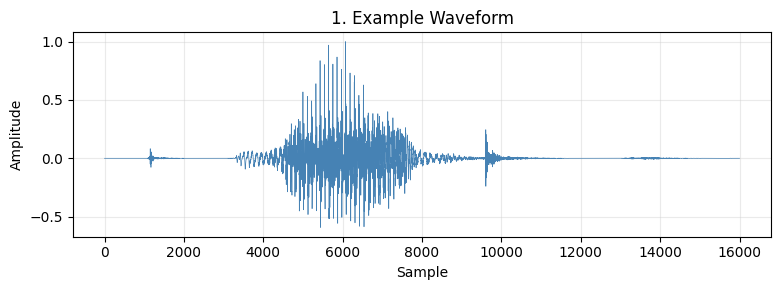

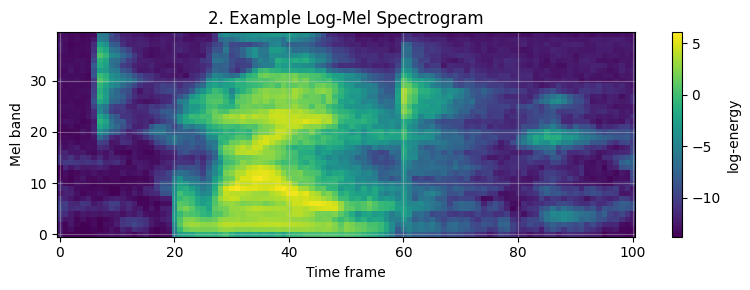

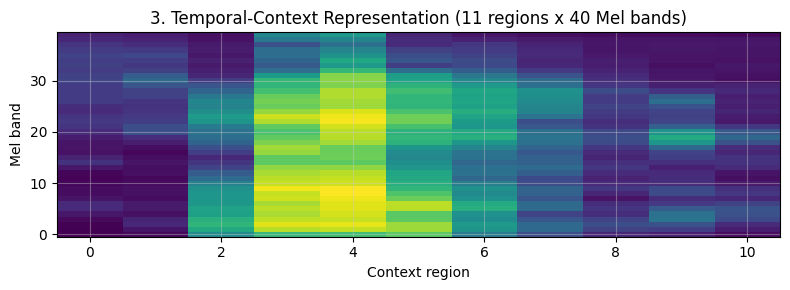

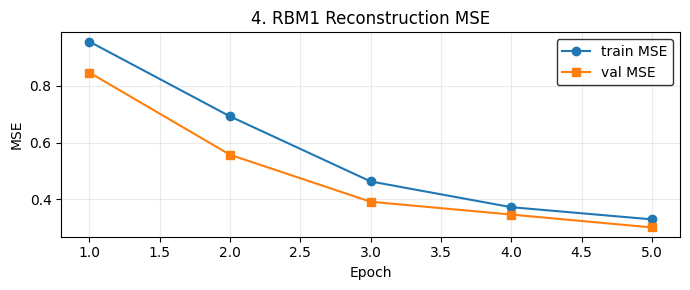

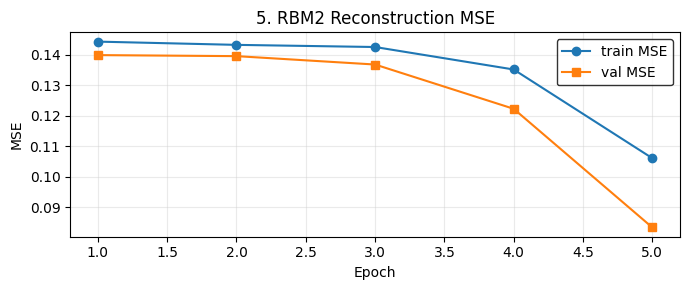

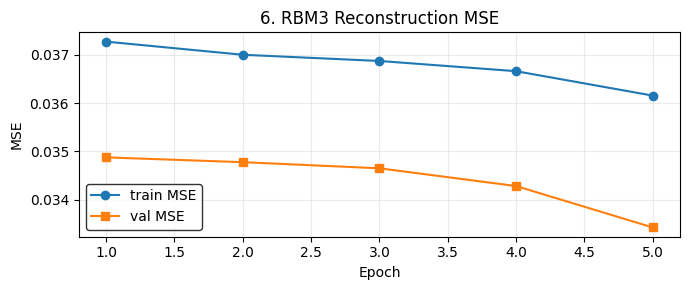

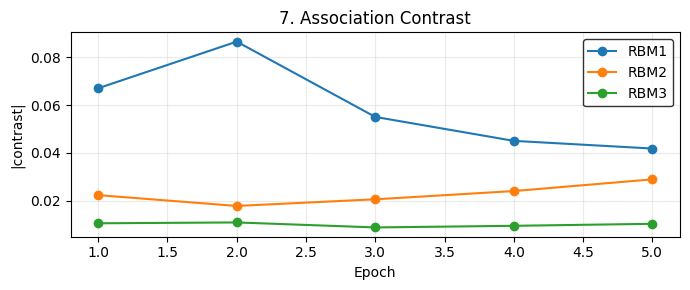

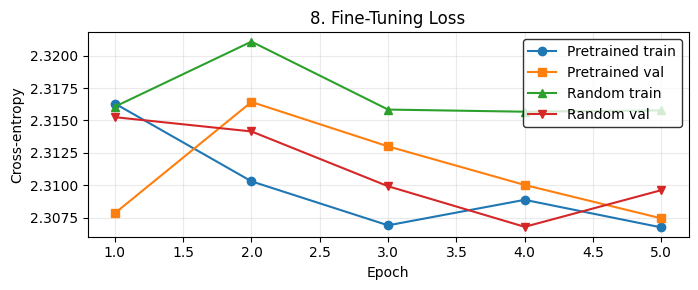

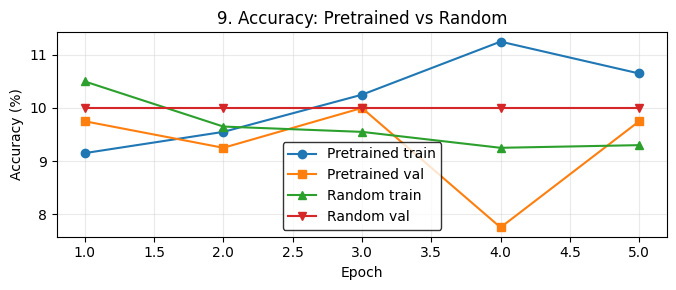

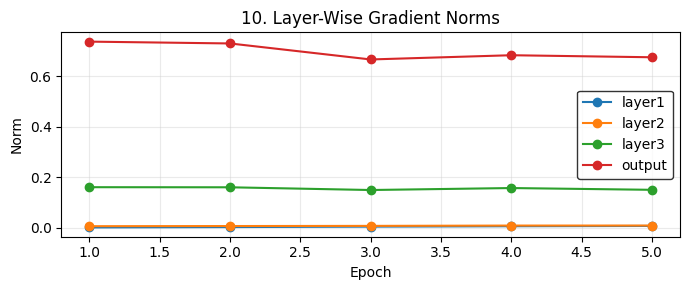

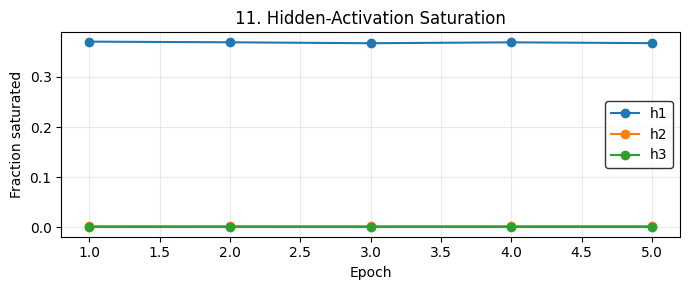

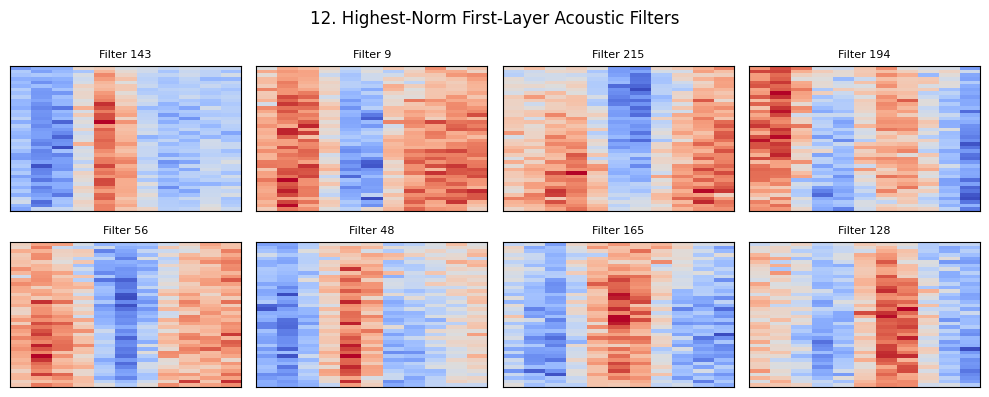

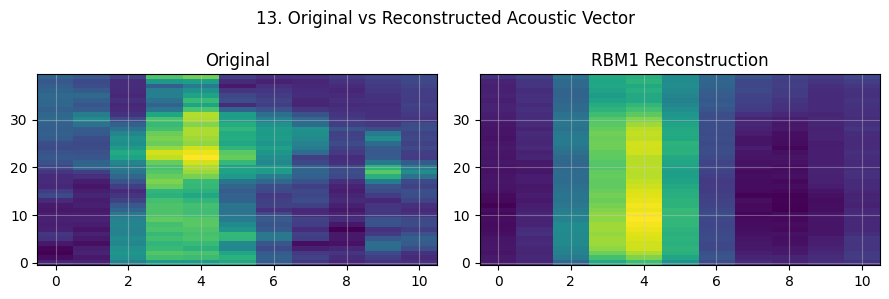

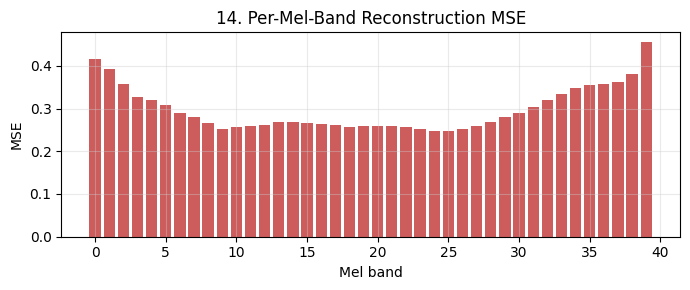

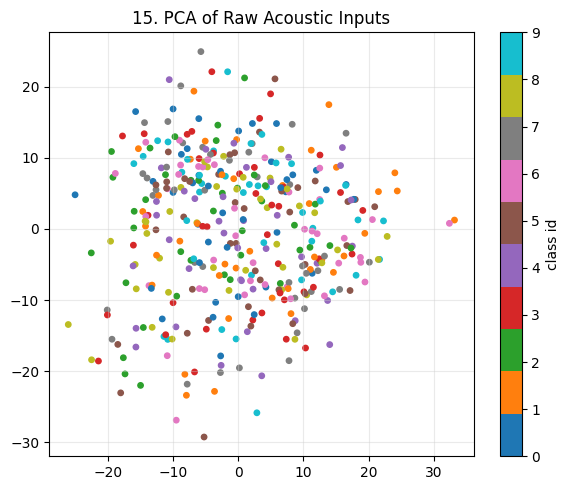

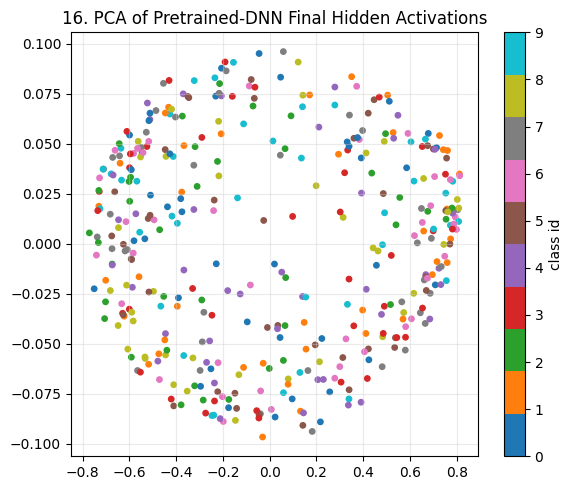

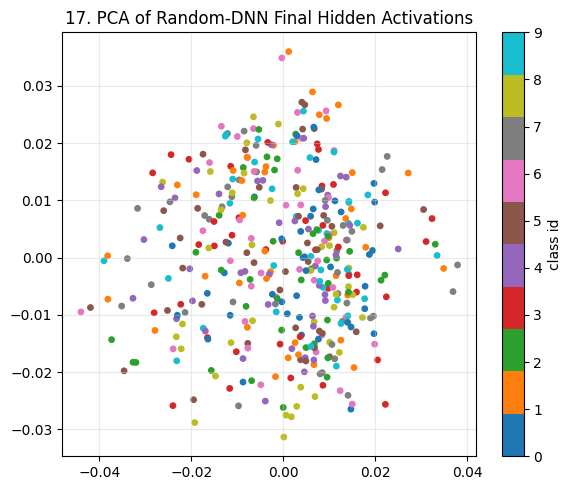

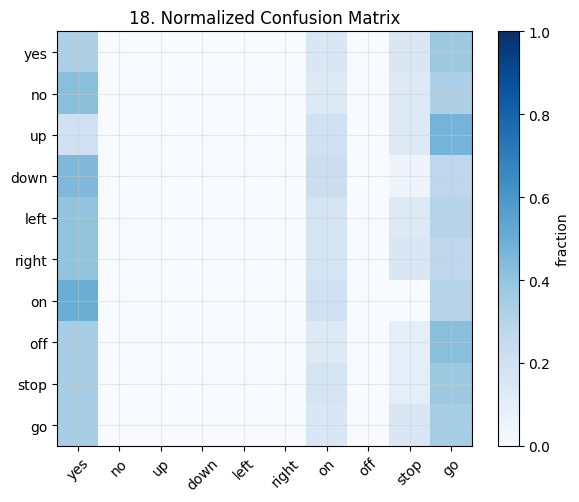

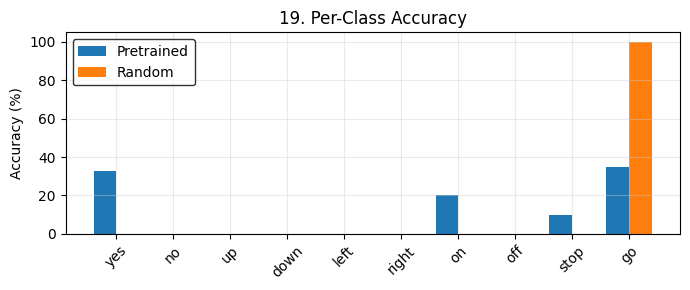

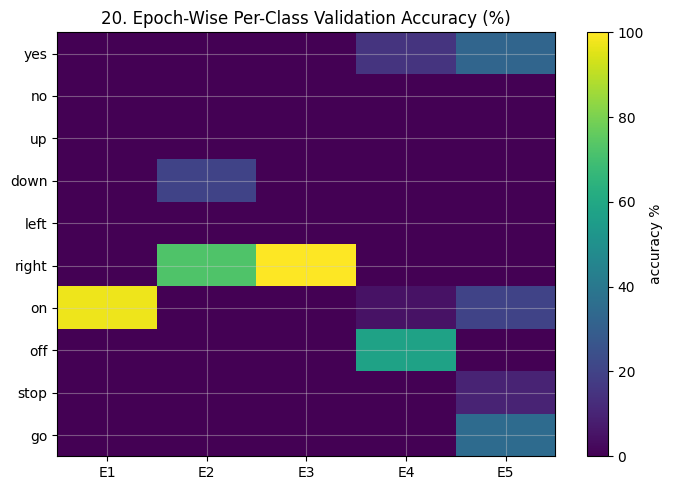

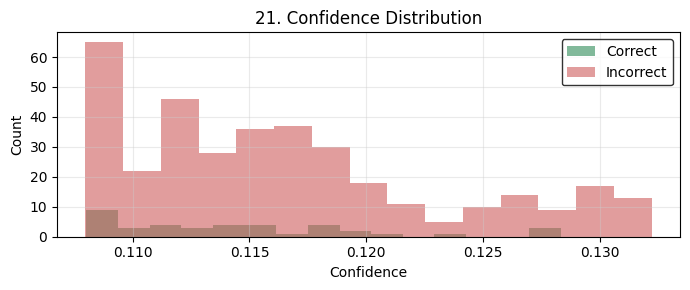

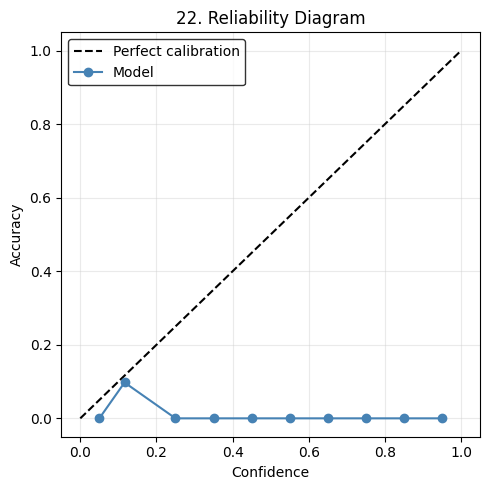

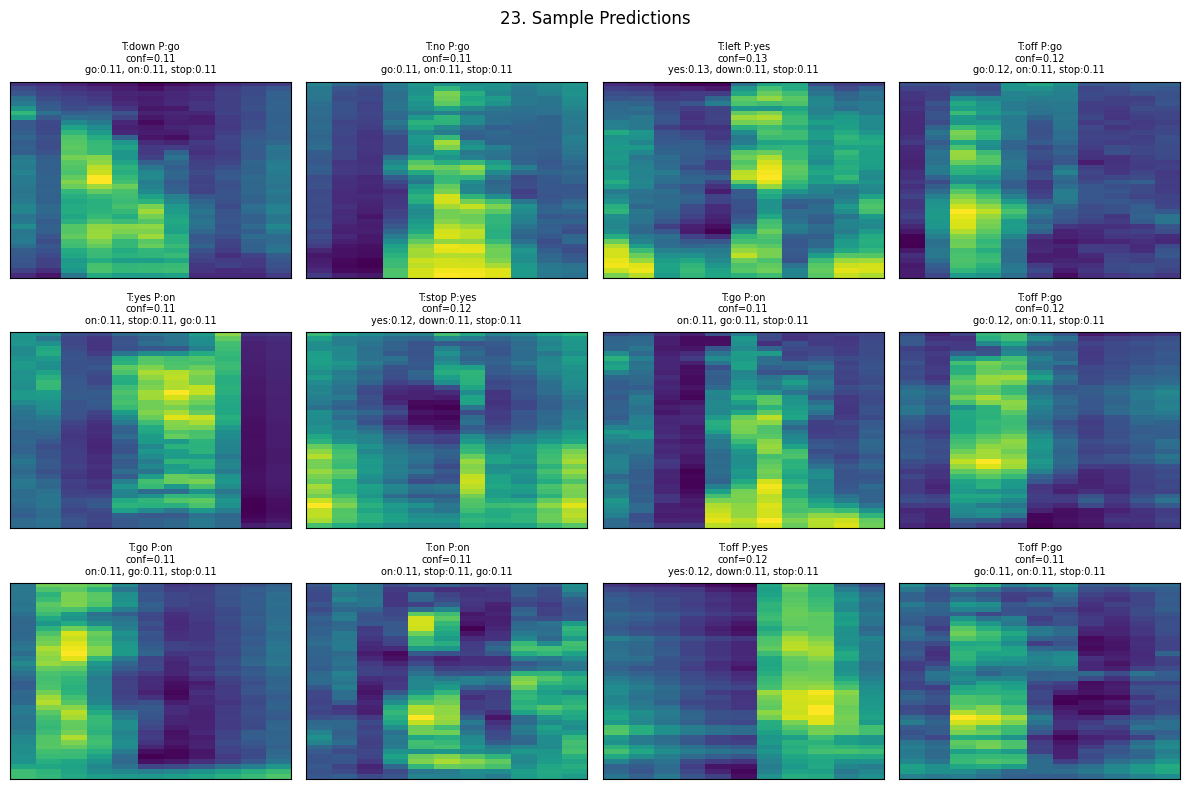

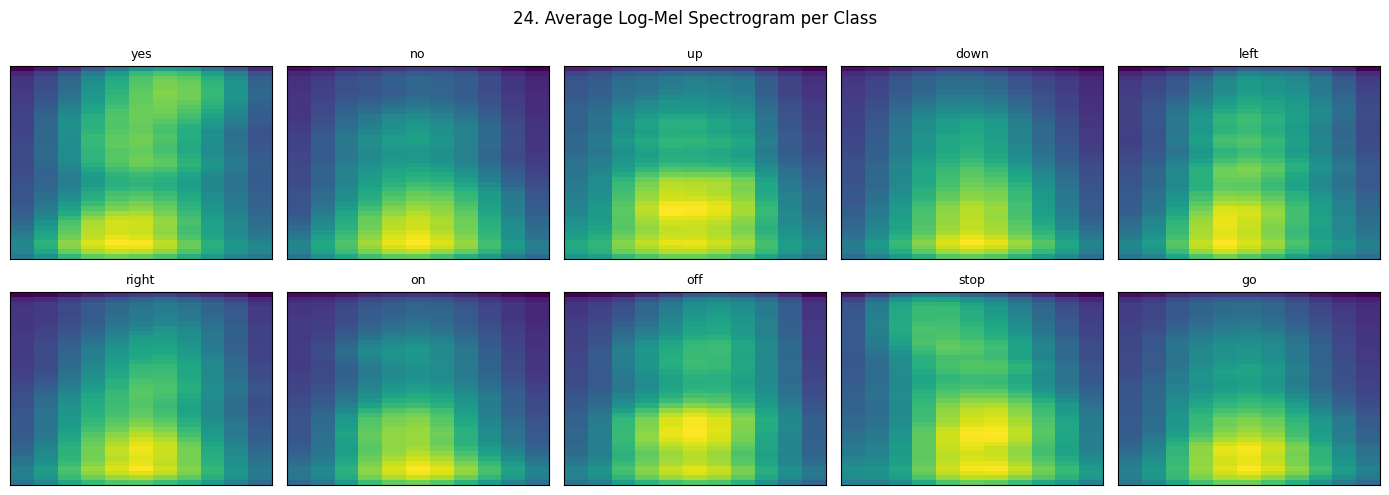

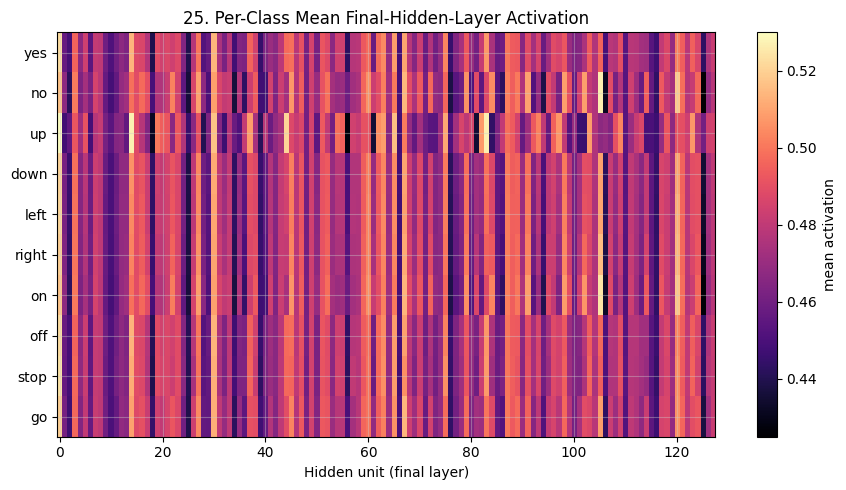

In [36]:
# ============================================================================
# STANDALONE VISUALIZATIONS
# ============================================================================
enforce_white_theme()
def show(fig):
    plt.tight_layout(); plt.show(); plt.close(fig)

fig = plt.figure(figsize=(8, 3))
plt.plot(example_wav.numpy(), color="steelblue", linewidth=0.5)
plt.title("1. Example Waveform"); plt.xlabel("Sample"); plt.ylabel("Amplitude"); show(fig)

fig = plt.figure(figsize=(8, 3))
plt.imshow(example_log_mel.numpy(), aspect="auto", origin="lower", cmap="viridis")
plt.title("2. Example Log-Mel Spectrogram"); plt.xlabel("Time frame"); plt.ylabel("Mel band")
plt.colorbar(label="log-energy"); show(fig)

fig = plt.figure(figsize=(8, 3))
plt.imshow(train_feats_raw[0].view(CONTEXT_FRAMES, N_MELS).numpy().T, aspect="auto", origin="lower", cmap="viridis")
plt.title("3. Temporal-Context Representation (11 regions x 40 Mel bands)")
plt.xlabel("Context region"); plt.ylabel("Mel band"); show(fig)

for i, (name, m) in enumerate(rbm_metrics_all.items(), start=4):
    fig = plt.figure(figsize=(7, 3))
    epochs = range(1, PRETRAIN_EPOCHS + 1)
    plt.plot(epochs, m["train_mse"], marker="o", label="train MSE")
    plt.plot(epochs, m["val_mse"], marker="s", label="val MSE")
    plt.title(f"{i}. RBM{name} Reconstruction MSE"); plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); show(fig)

fig = plt.figure(figsize=(7, 3))
for name, m in rbm_metrics_all.items():
    plt.plot(range(1, PRETRAIN_EPOCHS + 1), m["assoc_contrast"], marker="o", label=f"RBM{name}")
plt.title("7. Association Contrast"); plt.xlabel("Epoch"); plt.ylabel("|contrast|"); plt.legend(); show(fig)

ep = range(1, FINE_TUNE_EPOCHS + 1)
fig = plt.figure(figsize=(7, 3))
plt.plot(ep, [h["loss"] for h in pretrained_history["train"]], marker="o", label="Pretrained train")
plt.plot(ep, [h["loss"] for h in pretrained_history["val"]], marker="s", label="Pretrained val")
plt.plot(ep, [h["loss"] for h in random_history["train"]], marker="^", label="Random train")
plt.plot(ep, [h["loss"] for h in random_history["val"]], marker="v", label="Random val")
plt.title("8. Fine-Tuning Loss"); plt.xlabel("Epoch"); plt.ylabel("Cross-entropy"); plt.legend(); show(fig)

fig = plt.figure(figsize=(7, 3))
plt.plot(ep, [h["accuracy"] * 100 for h in pretrained_history["train"]], marker="o", label="Pretrained train")
plt.plot(ep, [h["accuracy"] * 100 for h in pretrained_history["val"]], marker="s", label="Pretrained val")
plt.plot(ep, [h["accuracy"] * 100 for h in random_history["train"]], marker="^", label="Random train")
plt.plot(ep, [h["accuracy"] * 100 for h in random_history["val"]], marker="v", label="Random val")
plt.title("9. Accuracy: Pretrained vs Random"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(); show(fig)

fig = plt.figure(figsize=(7, 3))
for layer_name in ["layer1", "layer2", "layer3", "output"]:
    plt.plot(ep, [h["grad_norms"][layer_name] for h in pretrained_history["train"]], marker="o", label=layer_name)
plt.title("10. Layer-Wise Gradient Norms"); plt.xlabel("Epoch"); plt.ylabel("Norm"); plt.legend(); show(fig)

fig = plt.figure(figsize=(7, 3))
for hname in ["h1", "h2", "h3"]:
    plt.plot(ep, [h["act_sat"][hname] for h in pretrained_history["train"]], marker="o", label=hname)
plt.title("11. Hidden-Activation Saturation"); plt.xlabel("Epoch"); plt.ylabel("Fraction saturated"); plt.legend(); show(fig)

fig, axes = plt.subplots(2, 4, figsize=(10, 4))
for ax, idx in zip(axes.flat, top_filter_idx):
    filt = rbm1.W[:, idx].detach().cpu().numpy().reshape(CONTEXT_FRAMES, N_MELS)
    ax.imshow(filt.T, aspect="auto", origin="lower", cmap="coolwarm")
    ax.set_title(f"Filter {idx}", fontsize=8); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("12. Highest-Norm First-Layer Acoustic Filters"); show(fig)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(X_train[0].cpu().view(CONTEXT_FRAMES, N_MELS).numpy().T, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Original")
axes[1].imshow(X_train_recon[0].cpu().view(CONTEXT_FRAMES, N_MELS).numpy().T, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("RBM1 Reconstruction")
fig.suptitle("13. Original vs Reconstructed Acoustic Vector"); show(fig)

fig = plt.figure(figsize=(7, 3))
plt.bar(range(N_MELS), per_mel_mse, color="indianred")
plt.title("14. Per-Mel-Band Reconstruction MSE"); plt.xlabel("Mel band"); plt.ylabel("MSE"); show(fig)

for i, (pts, title) in enumerate(
    [(pca_raw, "15. PCA of Raw Acoustic Inputs"),
     (pca_pretrained, "16. PCA of Pretrained-DNN Final Hidden Activations"),
     (pca_random, "17. PCA of Random-DNN Final Hidden Activations")]):
    fig = plt.figure(figsize=(6, 5))
    sc = plt.scatter(pts[:, 0], pts[:, 1], c=y_val_np, cmap="tab10", s=15)
    plt.title(title); plt.colorbar(sc, label="class id"); show(fig)

conf_mat = np.zeros((N_CLASSES, N_CLASSES))
for t, p in zip(final_pretrained_val["labels"], final_pretrained_val["preds"]):
    conf_mat[t, p] += 1
conf_mat_norm = conf_mat / np.maximum(conf_mat.sum(axis=1, keepdims=True), 1)
fig = plt.figure(figsize=(6, 5))
plt.imshow(conf_mat_norm, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(N_CLASSES), class_names, rotation=45); plt.yticks(range(N_CLASSES), class_names)
plt.title("18. Normalized Confusion Matrix"); plt.colorbar(label="fraction"); show(fig)

fig = plt.figure(figsize=(7, 3))
x = np.arange(N_CLASSES)
plt.bar(x - 0.2, final_pretrained_val["per_class_accuracy"] * 100, width=0.4, label="Pretrained")
plt.bar(x + 0.2, final_random_val["per_class_accuracy"] * 100, width=0.4, label="Random")
plt.xticks(x, class_names, rotation=45); plt.title("19. Per-Class Accuracy"); plt.ylabel("Accuracy (%)"); plt.legend(); show(fig)

epoch_class_matrix = np.stack([h["per_class_accuracy"] for h in pretrained_history["val"]], axis=1) * 100
fig = plt.figure(figsize=(7, 5))
plt.imshow(epoch_class_matrix, aspect="auto", cmap="viridis")
plt.yticks(range(N_CLASSES), class_names); plt.xticks(range(FINE_TUNE_EPOCHS), [f"E{i+1}" for i in range(FINE_TUNE_EPOCHS)])
plt.title("20. Epoch-Wise Per-Class Validation Accuracy (%)"); plt.colorbar(label="accuracy %"); show(fig)

probs_arr, preds_arr, labels_arr = final_pretrained_val["probs"], final_pretrained_val["preds"], final_pretrained_val["labels"]
conf_arr = probs_arr.max(axis=1)
correct_mask_np = preds_arr == labels_arr
fig = plt.figure(figsize=(7, 3))
plt.hist(conf_arr[correct_mask_np], bins=15, alpha=0.6, label="Correct", color="seagreen")
plt.hist(conf_arr[~correct_mask_np], bins=15, alpha=0.6, label="Incorrect", color="indianred")
plt.title("21. Confidence Distribution"); plt.xlabel("Confidence"); plt.ylabel("Count"); plt.legend(); show(fig)

n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_acc, bin_conf = [], []
for i in range(n_bins):
    mask = (conf_arr > bin_edges[i]) & (conf_arr <= bin_edges[i + 1])
    if mask.sum() > 0:
        bin_acc.append((preds_arr[mask] == labels_arr[mask]).mean()); bin_conf.append(conf_arr[mask].mean())
    else:
        bin_acc.append(0); bin_conf.append((bin_edges[i] + bin_edges[i + 1]) / 2)
fig = plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(bin_conf, bin_acc, marker="o", color="steelblue", label="Model")
plt.title("22. Reliability Diagram"); plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.legend(); show(fig)

sample_indices = np.random.RandomState(SEED).choice(len(y_val_np), 12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for ax, idx in zip(axes.flat, sample_indices):
    top3 = np.argsort(-probs_arr[idx])[:3]
    top3_str = ", ".join(f"{class_names[j]}:{probs_arr[idx][j]:.2f}" for j in top3)
    ax.imshow(X_val_np[idx].reshape(CONTEXT_FRAMES, N_MELS).T, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"T:{class_names[labels_arr[idx]]} P:{class_names[preds_arr[idx]]}\n"
                 f"conf={conf_arr[idx]:.2f}\n{top3_str}", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("23. Sample Predictions"); show(fig)

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for ax, c in zip(axes.flat, range(N_CLASSES)):
    if c in avg_spectrogram_per_class:
        ax.imshow(avg_spectrogram_per_class[c].T, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(class_names[c], fontsize=9); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("24. Average Log-Mel Spectrogram per Class"); show(fig)

per_class_hidden_mean = np.zeros((N_CLASSES, h3_pretrained_np.shape[1]))
for c in range(N_CLASSES):
    mask = y_val_np == c
    if mask.sum() > 0:
        per_class_hidden_mean[c] = h3_pretrained_np[mask].mean(axis=0)
fig = plt.figure(figsize=(9, 5))
plt.imshow(per_class_hidden_mean, aspect="auto", cmap="magma")
plt.yticks(range(N_CLASSES), class_names); plt.xlabel("Hidden unit (final layer)")
plt.title("25. Per-Class Mean Final-Hidden-Layer Activation"); plt.colorbar(label="mean activation"); show(fig)

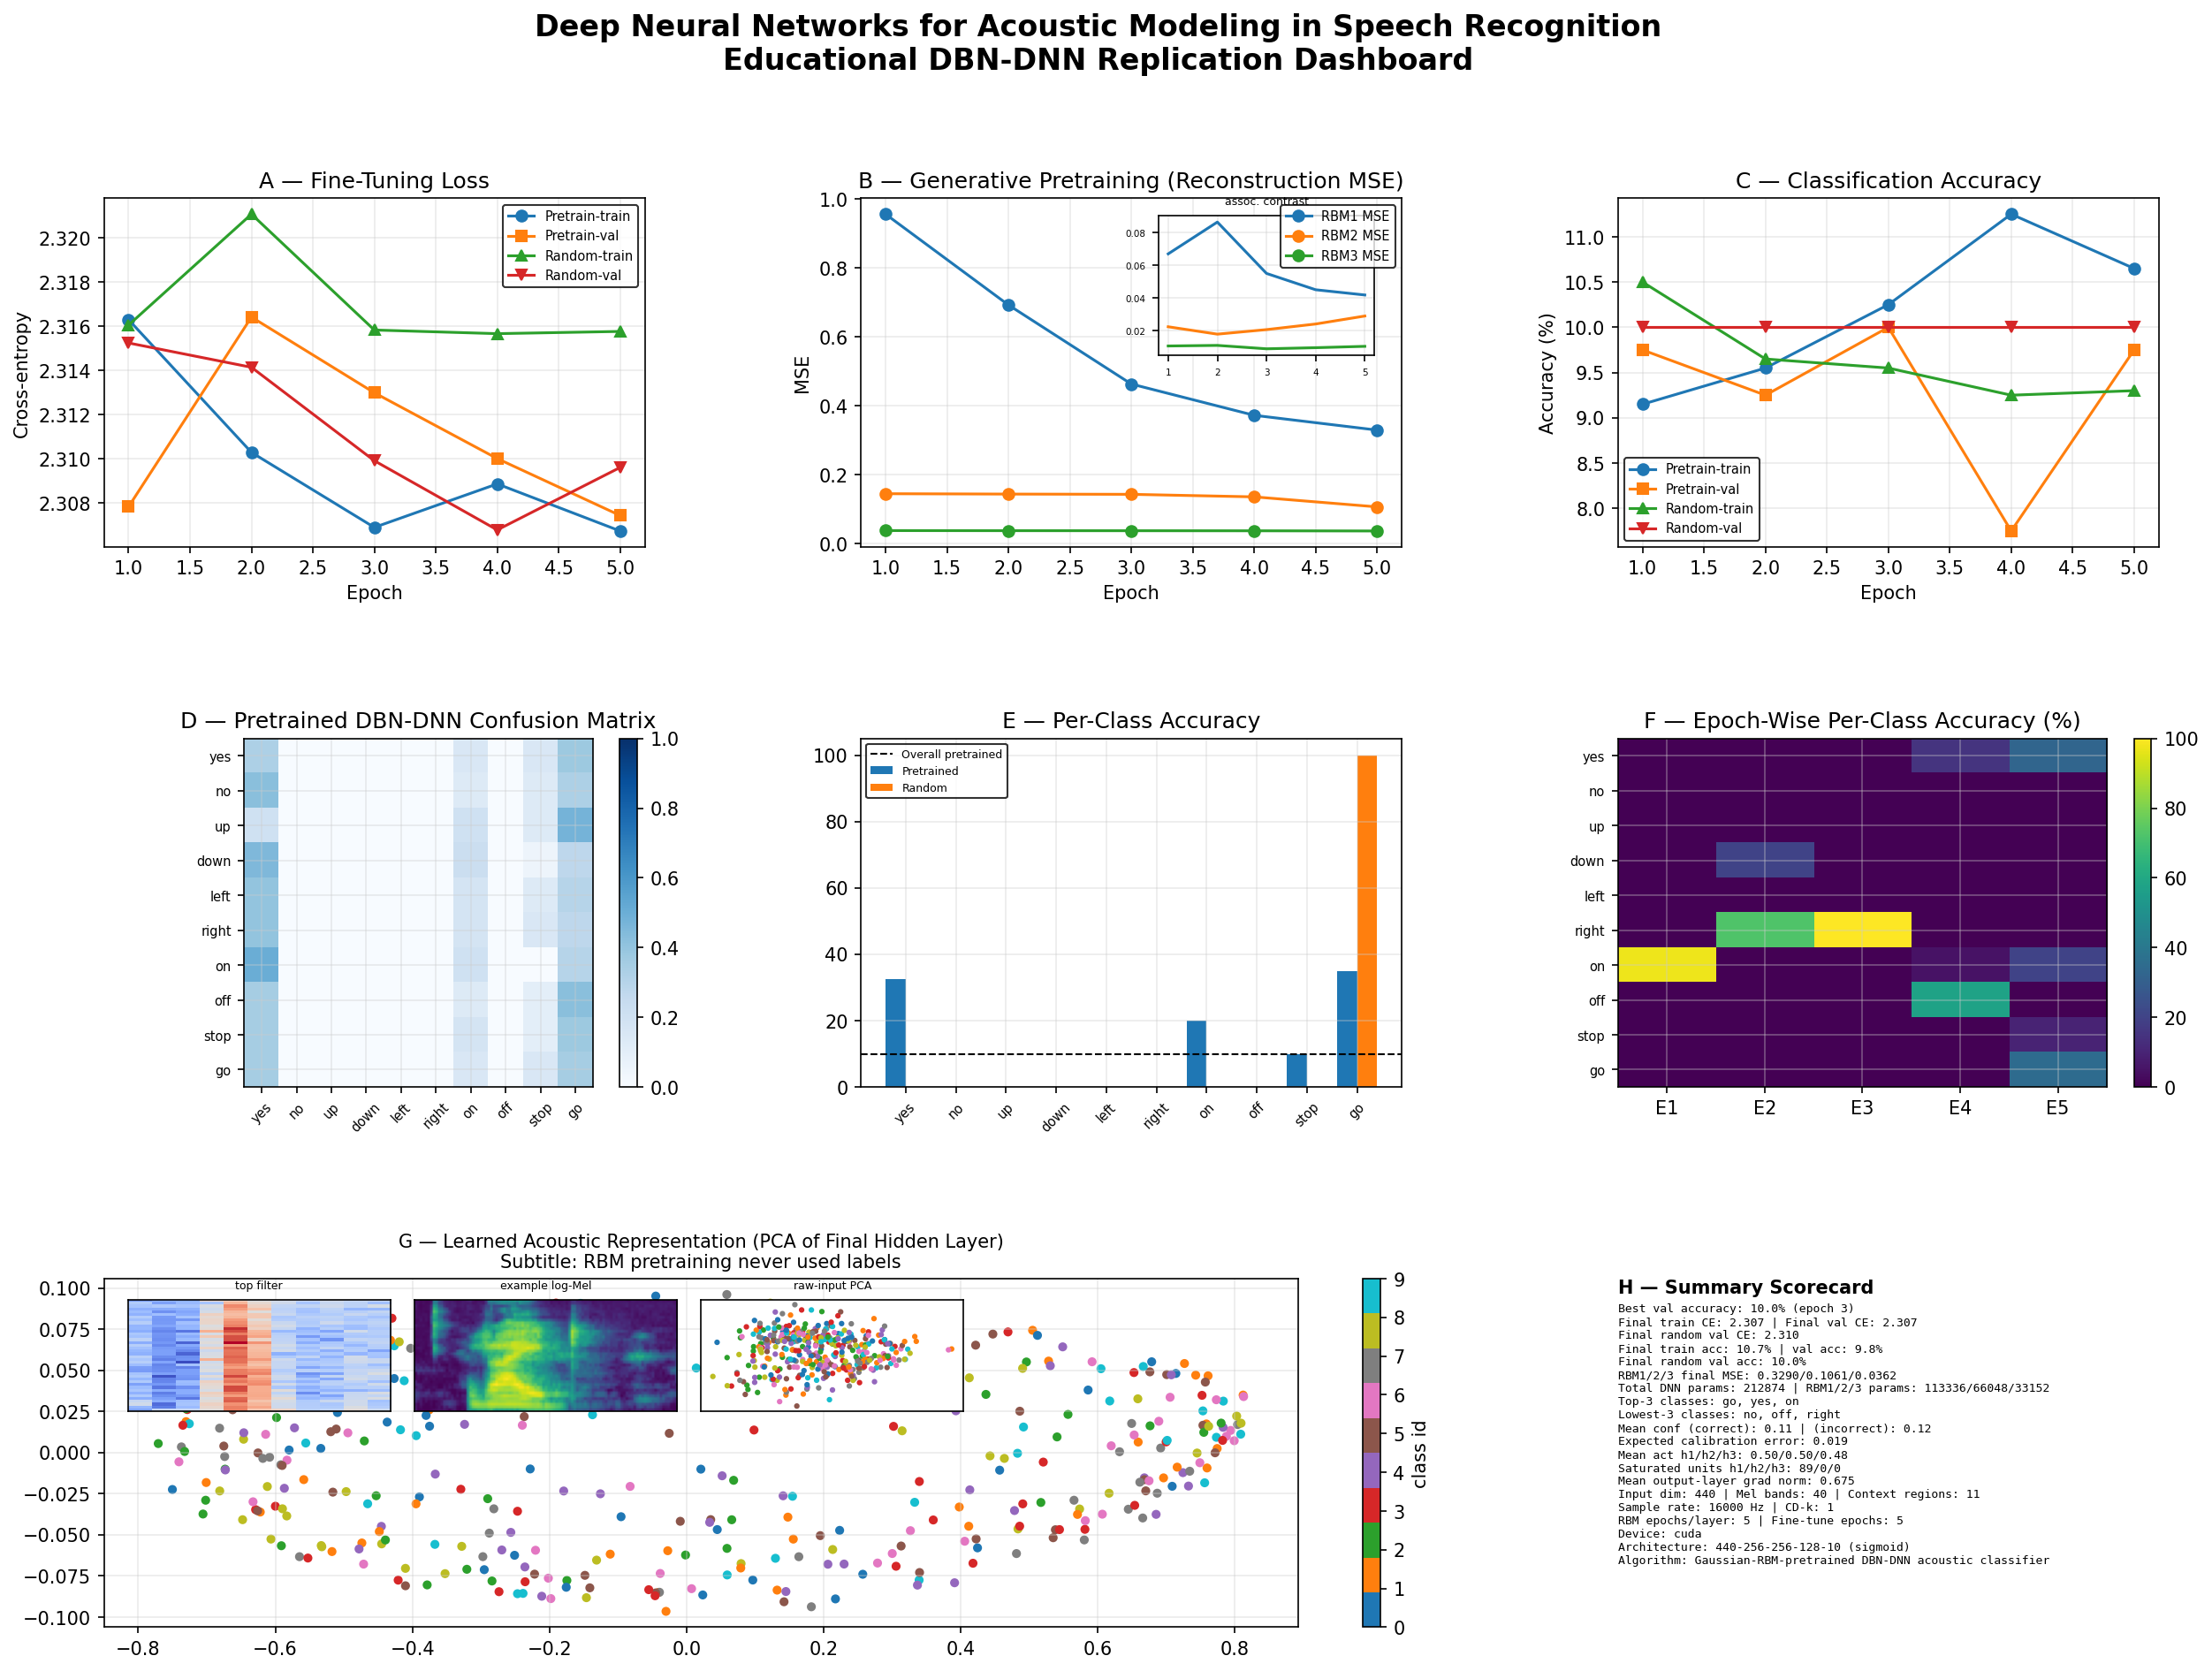

In [37]:
# ============================================================================
# FINAL DASHBOARD (8 panels, A-H, must be last)
# ============================================================================
enforce_white_theme()
fig = plt.figure(figsize=(20, 14), facecolor="white")
fig.suptitle("Deep Neural Networks for Acoustic Modeling in Speech Recognition\n"
             "Educational DBN-DNN Replication Dashboard", fontsize=16, color="black", fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

axA = fig.add_subplot(gs[0, 0])
axA.plot(ep, [h["loss"] for h in pretrained_history["train"]], marker="o", label="Pretrain-train")
axA.plot(ep, [h["loss"] for h in pretrained_history["val"]], marker="s", label="Pretrain-val")
axA.plot(ep, [h["loss"] for h in random_history["train"]], marker="^", label="Random-train")
axA.plot(ep, [h["loss"] for h in random_history["val"]], marker="v", label="Random-val")
axA.set_title("A — Fine-Tuning Loss", color="black"); axA.set_xlabel("Epoch"); axA.set_ylabel("Cross-entropy"); axA.legend(fontsize=7)

axB = fig.add_subplot(gs[0, 1])
for name, m in rbm_metrics_all.items():
    axB.plot(range(1, PRETRAIN_EPOCHS + 1), m["train_mse"], marker="o", label=f"RBM{name} MSE")
axB.set_title("B — Generative Pretraining (Reconstruction MSE)", color="black")
axB.set_xlabel("Epoch"); axB.set_ylabel("MSE"); axB.legend(fontsize=7)
axB_inset = axB.inset_axes([0.55, 0.55, 0.4, 0.4])
for name, m in rbm_metrics_all.items():
    axB_inset.plot(range(1, PRETRAIN_EPOCHS + 1), m["assoc_contrast"])
axB_inset.set_title("assoc. contrast", fontsize=6); axB_inset.tick_params(labelsize=5)

axC = fig.add_subplot(gs[0, 2])
axC.plot(ep, [h["accuracy"] * 100 for h in pretrained_history["train"]], marker="o", label="Pretrain-train")
axC.plot(ep, [h["accuracy"] * 100 for h in pretrained_history["val"]], marker="s", label="Pretrain-val")
axC.plot(ep, [h["accuracy"] * 100 for h in random_history["train"]], marker="^", label="Random-train")
axC.plot(ep, [h["accuracy"] * 100 for h in random_history["val"]], marker="v", label="Random-val")
axC.set_title("C — Classification Accuracy", color="black"); axC.set_xlabel("Epoch"); axC.set_ylabel("Accuracy (%)"); axC.legend(fontsize=7)

axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(conf_mat_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(N_CLASSES)); axD.set_xticklabels(class_names, rotation=45, fontsize=7)
axD.set_yticks(range(N_CLASSES)); axD.set_yticklabels(class_names, fontsize=7)
axD.set_title("D — Pretrained DBN-DNN Confusion Matrix", color="black"); fig.colorbar(imD, ax=axD, fraction=0.046)

axE = fig.add_subplot(gs[1, 1])
axE.bar(x - 0.2, final_pretrained_val["per_class_accuracy"] * 100, width=0.4, label="Pretrained")
axE.bar(x + 0.2, final_random_val["per_class_accuracy"] * 100, width=0.4, label="Random")
axE.axhline(final_pretrained_val["accuracy"] * 100, color="black", linestyle="--", linewidth=1, label="Overall pretrained")
axE.set_xticks(x); axE.set_xticklabels(class_names, rotation=45, fontsize=7)
axE.set_title("E — Per-Class Accuracy", color="black"); axE.legend(fontsize=6)

axF = fig.add_subplot(gs[1, 2])
imF = axF.imshow(epoch_class_matrix, aspect="auto", cmap="viridis")
axF.set_yticks(range(N_CLASSES)); axF.set_yticklabels(class_names, fontsize=7)
axF.set_xticks(range(FINE_TUNE_EPOCHS)); axF.set_xticklabels([f"E{i+1}" for i in range(FINE_TUNE_EPOCHS)])
axF.set_title("F — Epoch-Wise Per-Class Accuracy (%)", color="black"); fig.colorbar(imF, ax=axF, fraction=0.046)

axG = fig.add_subplot(gs[2, 0:2])
scG = axG.scatter(pca_pretrained[:, 0], pca_pretrained[:, 1], c=y_val_np, cmap="tab10", s=15)
axG.set_title("G — Learned Acoustic Representation (PCA of Final Hidden Layer)\n"
              "Subtitle: RBM pretraining never used labels", color="black", fontsize=10)
fig.colorbar(scG, ax=axG, fraction=0.03, label="class id")
axG_i1 = axG.inset_axes([0.02, 0.62, 0.22, 0.32])
filt0 = rbm1.W[:, top_filter_idx[0]].detach().cpu().numpy().reshape(CONTEXT_FRAMES, N_MELS)
axG_i1.imshow(filt0.T, aspect="auto", origin="lower", cmap="coolwarm")
axG_i1.set_title("top filter", fontsize=6); axG_i1.set_xticks([]); axG_i1.set_yticks([])
axG_i2 = axG.inset_axes([0.26, 0.62, 0.22, 0.32])
axG_i2.imshow(example_log_mel.numpy(), aspect="auto", origin="lower", cmap="viridis")
axG_i2.set_title("example log-Mel", fontsize=6); axG_i2.set_xticks([]); axG_i2.set_yticks([])
axG_i3 = axG.inset_axes([0.50, 0.62, 0.22, 0.32])
axG_i3.scatter(pca_raw[:, 0], pca_raw[:, 1], c=y_val_np, cmap="tab10", s=4)
axG_i3.set_title("raw-input PCA", fontsize=6); axG_i3.set_xticks([]); axG_i3.set_yticks([])

axH = fig.add_subplot(gs[2, 2]); axH.axis("off")
best_epoch = int(np.argmax([h["accuracy"] for h in pretrained_history["val"]])) + 1
best_val_acc = max(h["accuracy"] for h in pretrained_history["val"])
final_pt, final_pv, final_rv = pretrained_history["train"][-1], pretrained_history["val"][-1], random_history["val"][-1]
n_params_total = sum(p.numel() for p in pretrained_dnn.parameters())
n_params_rbm1 = rbm1.W.numel() + rbm1.visible_bias.numel() + rbm1.hidden_bias.numel()
n_params_rbm2 = rbm2.W.numel() + rbm2.visible_bias.numel() + rbm2.hidden_bias.numel()
n_params_rbm3 = rbm3.W.numel() + rbm3.visible_bias.numel() + rbm3.hidden_bias.numel()
sorted_classes = np.argsort(-final_pretrained_val["per_class_accuracy"])
top3_classes = [class_names[i] for i in sorted_classes[:3]]
bottom3_classes = [class_names[i] for i in sorted_classes[-3:]]
sat_counts = {
    "h1": int(final_pv["act_sat"]["h1"] * pretrained_dnn.layer1.out_features),
    "h2": int(final_pv["act_sat"]["h2"] * pretrained_dnn.layer2.out_features),
    "h3": int(final_pv["act_sat"]["h3"] * pretrained_dnn.layer3.out_features),
}
scorecard_lines = [
    f"Best val accuracy: {best_val_acc*100:.1f}% (epoch {best_epoch})",
    f"Final train CE: {final_pt['loss']:.3f} | Final val CE: {final_pv['loss']:.3f}",
    f"Final random val CE: {final_rv['loss']:.3f}",
    f"Final train acc: {final_pt['accuracy']*100:.1f}% | val acc: {final_pv['accuracy']*100:.1f}%",
    f"Final random val acc: {final_rv['accuracy']*100:.1f}%",
    f"RBM1/2/3 final MSE: {rbm1_metrics['train_mse'][-1]:.4f}/{rbm2_metrics['train_mse'][-1]:.4f}/{rbm3_metrics['train_mse'][-1]:.4f}",
    f"Total DNN params: {n_params_total} | RBM1/2/3 params: {n_params_rbm1}/{n_params_rbm2}/{n_params_rbm3}",
    f"Top-3 classes: {', '.join(top3_classes)}",
    f"Lowest-3 classes: {', '.join(bottom3_classes)}",
    f"Mean conf (correct): {final_pv['mean_conf_correct']:.2f} | (incorrect): {final_pv['mean_conf_incorrect']:.2f}",
    f"Expected calibration error: {final_pv['ece']:.3f}",
    f"Mean act h1/h2/h3: {final_pv['act_means']['h1']:.2f}/{final_pv['act_means']['h2']:.2f}/{final_pv['act_means']['h3']:.2f}",
    f"Saturated units h1/h2/h3: {sat_counts['h1']}/{sat_counts['h2']}/{sat_counts['h3']}",
    f"Mean output-layer grad norm: {final_pt['grad_norms']['output']:.3f}",
    f"Input dim: {INPUT_DIM} | Mel bands: {N_MELS} | Context regions: {CONTEXT_FRAMES}",
    f"Sample rate: {SAMPLE_RATE} Hz | CD-k: {CD_K}",
    f"RBM epochs/layer: {PRETRAIN_EPOCHS} | Fine-tune epochs: {FINE_TUNE_EPOCHS}",
    f"Device: {DEVICE}",
    "Architecture: 440-256-256-128-10 (sigmoid)",
    "Algorithm: Gaussian-RBM-pretrained DBN-DNN acoustic classifier",
]
axH.text(0.0, 1.0, "H — Summary Scorecard", fontsize=10, fontweight="bold", color="black", va="top", transform=axH.transAxes)
axH.text(0.0, 0.93, "\n".join(scorecard_lines), fontsize=6.3, color="black", va="top",
         transform=axH.transAxes, family="monospace")

buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Experimental Results Analysis: Educational DBN-DNN Replication (Speech Commands, 10-Class)

## 1. RBM Generative Pretraining — Reconstruction Curves (Panel B)

### Overview
Panel B tracks reconstruction MSE across five CD-1 training epochs for the three stacked RBMs (Gaussian-Bernoulli RBM1: 440→256; Bernoulli RBM2: 256→256; Bernoulli RBM3: 256→128), the unsupervised pretraining stage of the DBN-DNN pipeline.

### Key Findings
- RBM1 MSE decreases substantially and monotonically (≈0.95 → 0.33), indicating the model is progressively learning to reconstruct standardized log-Mel context vectors.
- RBM2 and RBM3 plateau almost immediately at low, near-constant MSE (~0.14 and ~0.04, respectively).
- The association-contrast inset shows a similar early-epoch adjustment followed by decay toward small values across all three RBMs.

### Discussion
The clear downward trend for RBM1 demonstrates that Contrastive Divergence is functioning correctly for the bottom, real-valued layer and that meaningful low-level acoustic structure is being captured. The rapid, low-MSE plateau for RBM2/RBM3, however, is more consistent with representational collapse than successful higher-order feature learning: once RBM1's hidden probabilities are used as inputs, they may already be poorly separated or close to constant across examples, making trivial reconstructions easy to achieve. This is a common failure mode when the underlying features passed upward carry limited information, or when learning rate/momentum settings cause the higher RBMs to fall into a narrow, low-energy solution quickly.

### Limitations
No log-likelihood or pseudo-likelihood curves are shown for the Gaussian layer, and reconstruction MSE alone cannot confirm whether the learned hidden units encode class-discriminative structure — this must be checked against the downstream classification and embedding results (Panels D–G), which suggest they largely do not.

---

## 2. Discriminative Fine-Tuning: Loss and Accuracy Curves (Panels A, C)

### Overview
These panels compare training/validation cross-entropy (A) and accuracy (C) over five fine-tuning epochs for the RBM-pretrained DBN-DNN versus a randomly initialized DNN of identical architecture, the paper's core "pretraining benefit" comparison.

### Key Findings
- Cross-entropy for both models oscillates narrowly around 2.307–2.322, close to ln(10) ≈ 2.303, the loss expected from uniform 10-way random guessing.
- Validation accuracy fluctuates between ~8% and ~11.5% for both models, centered near the 10% chance baseline for 10 balanced classes.
- Neither model shows a stable, monotonic decrease in loss or increase in accuracy across epochs; curves are noisy and non-convergent.
- No consistent separation emerges between the pretrained and randomly initialized models — their final validation accuracies (9.8% vs. 10.0%) are statistically indistinguishable.

### Discussion
This behavior indicates that neither model is learning a useful class-discriminative mapping within the given training budget. The proximity of the loss to ln(10) throughout training suggests the softmax outputs remain close to uniform, rather than sharpening toward correct classes. This directly undermines the paper's central claim — that generative pretraining provides a superior initialization for discriminative fine-tuning — since no advantage of the pretrained model over the random baseline is observed here. Likely contributing factors include an insufficient number of fine-tuning epochs (5) for this architecture/optimizer combination, a learning rate/momentum configuration poorly suited to a small (2,000-example) dataset, or an information bottleneck introduced during feature extraction (e.g., temporal-region-averaging of the log-Mel spectrogram) that removes cues needed to separate spoken words.

### Discrepancy with the paper's original findings
The source paper reports pretraining reducing WER substantially relative to strong baselines on large-vocabulary, thousands-of-hours datasets. Here, the small-scale/short-training educational reproduction does not reproduce that effect, and should be interpreted as a demonstration of the *mechanism* only, not as validation of the original paper's quantitative claims.

### Limitations
With only five fine-tuning epochs and 2,000 training examples for 440-dimensional, sigmoid-activated inputs, the experiment is likely under-trained; conclusions about the intrinsic value of pretraining cannot be drawn from this scale alone.

---

## 3. Confusion Matrix and Per-Class Accuracy (Panels D, E, F)

### Overview
Panel D shows the row-normalized confusion matrix for the pretrained model at the final epoch; Panel E compares per-class accuracy between pretrained and random models; Panel F tracks per-class validation accuracy across all five fine-tuning epochs for the pretrained model.

### Key Findings
- The confusion matrix (D) shows nearly all predictive mass concentrated in a handful of columns ("yes," "on," "stop," "go"), regardless of the true class — i.e., most rows are predicted into the same few classes.
- Per-class accuracy (E) confirms this: the pretrained model achieves non-trivial accuracy only for "yes," "on," and "stop," while six of ten classes receive 0% accuracy. The random-init model collapses entirely, predicting "go" for essentially all inputs (100% accuracy for "go," 0% elsewhere).
- The epoch-wise heatmap (F) shows the pretrained model's single "active" prediction class shifting from epoch to epoch (e.g., "on" dominates epoch 1, "right" dominates epochs 2–3, "off" dominates epochs 4–5), rather than progressively improving across all classes simultaneously.

### Discussion
This pattern is a textbook signature of mode collapse in the softmax output layer rather than genuine multi-class discrimination: the network learns to default to whichever single class currently minimizes aggregate cross-entropy loss, and this preferred class drifts as SGD updates perturb the output layer, without the hidden representations becoming more class-separable. The random-init baseline's complete collapse to one class is consistent with a poorly conditioned optimization trajectory from a cold start, while the pretrained model's partial, unstable multi-class behavior suggests pretraining provides a marginally better starting region in weight space but still fails to produce a well-separated decision boundary given the limited fine-tuning budget.

### Discrepancy with the paper's original findings
This behavior does not support the paper's claims of consistent, stable state-recognition benefits from DBN pretraining; the current setup demonstrates the training *procedure* but not the intended *outcome*.

### Limitations
The small held-out set (400 examples, ~40 per class) makes per-class accuracy estimates noisy, and the shifting single-class dominance pattern in Panel F could partly reflect optimizer instability (e.g., too-high effective learning rate for this batch size/momentum) rather than being solely a data or architecture limitation.

---

## 4. Learned Representation via PCA (Panel G)

### Overview
Panel G visualizes a 2D PCA projection of the pretrained DNN's final hidden layer (128 units) on the validation set, colored by true class, alongside inset visualizations of a top RBM1 filter, an example log-Mel spectrogram, and a raw-input PCA baseline for comparison.

### Key Findings
- Points from all ten classes are thoroughly intermixed across the PCA projection, with no visible per-class clusters or separable regions.
- The raw-input PCA inset shows a similarly undifferentiated point cloud, suggesting the lack of separability is present even before any learned transformation.
- The top RBM1 filter (inset) does show localized structure across specific Mel bands and context positions, indicating the RBM did learn some non-trivial, spatially organized acoustic filters at the input level.

### Discussion
The absence of class clustering in both the raw-feature PCA and the final hidden-layer PCA indicates that the discriminative information needed to separate these ten spoken words is not linearly recoverable from either the raw 440-dimensional context features or the learned 128-dimensional representation, at least in the two principal components shown. Since the RBM filters do show structured, non-random patterns, the unsupervised pretraining stage is functioning as intended at the filter level; the failure to produce class-relevant structure is more attributable to the shallow, low-resolution context-pooling feature extraction (11 averaged temporal regions) and limited fine-tuning than to a fundamental failure of the RBM/DBN mechanism itself.

### Limitations
A 2D PCA projection captures only a small fraction of variance in a 128-dimensional space and may understate genuine (if higher-dimensional) discriminative structure; a linear probe or t-SNE/UMAP projection would provide a more robust separability assessment.

---

## 5. Summary Scorecard (Panel H)

### Overview
Panel H aggregates final quantitative outcomes: best/final accuracy and loss for both models, RBM reconstruction errors, parameter counts, calibration statistics, and architecture/hyperparameter metadata.

### Key Findings
- Best pretrained validation accuracy across all epochs is 10.0% (epoch 3) — statistically at chance for 10 balanced classes.
- Final pretrained vs. random validation accuracy (9.8% vs. 10.0%) and cross-entropy (2.307 vs. 2.310) are nearly identical.
- Expected calibration error is low (0.019), but this reflects a model outputting persistently low-confidence, near-uniform predictions rather than well-calibrated confident ones (mean confidence for correct predictions is only 0.11, barely above the 0.10 chance level).
- RBM1 achieves markedly lower final reconstruction MSE (0.329) than the higher layers (0.106, 0.036), consistent with Panel B.

### Discussion
The scorecard confirms, in aggregate, what the individual panels show piecewise: unsupervised pretraining produced structured low-level filters and successful reconstruction learning, but this did not translate into a discriminatively useful DNN under the current experimental budget. The near-uniform confidence and at-chance accuracy indicate the classifier essentially failed to learn a non-trivial input-output mapping, which is the central negative result of this replication.

### Discrepancy with the paper's original findings
The original paper's central empirical claim — that DBN pretraining meaningfully improves recognition accuracy over comparable baselines — is not supported by this reduced-scale educational reproduction; the results should be read as illustrating the *mechanics* of the pipeline (RBM stacking, CD-1, DBN→DNN conversion, fine-tuning) rather than as a successful quantitative replication of the paper's reported gains.

### Limitations
Given the small dataset (2,000/400 examples), aggressively pooled temporal features, and only five fine-tuning epochs, these results cannot be generalized to claims about DBN pretraining's efficacy; a fair test would require substantially more training data, more epochs, hyperparameter tuning, and likely a richer (non-pooled) input representation more faithful to the paper's original frame-level, multi-thousand-hour setup.

# Related Work Extracted from Reference List

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| J. Baker, L. Deng, J. Glass, S. Khudanpur, Chin Hui Lee, N. Morgan, D. O'Shaughnessy | 2009 | Developments and directions in speech recognition and understanding, part 1 | IEEE Signal Processing Magazine | Reviews the history of ASR, providing context for the GMM-HMM paradigm this paper's DNN approach seeks to replace. |
| S. Furui | 2000 | Digital Speech Processing, Synthesis, and Recognition | Marcel Dekker | Standard reference on HMM-based speech recognition, establishing the baseline framework the paper builds upon. |
| B. H. Juang, S. Levinson, M. Sondhi | 1986 | Maximum likelihood estimation for multivariate mixture observations of Markov chains | IEEE Trans. Information Theory | Establishes EM-based GMM-HMM training, the generative baseline against which DNN acoustic models are compared. |
| H. Hermansky | 1990 | Perceptual linear predictive (PLP) analysis of speech | J. Acoust. Soc. Amer. | Introduces PLP features, one of the standard input representations used in this paper's acoustic modeling experiments. |
| S. Furui | 1981 | Cepstral analysis technique for automatic speaker verification | IEEE Trans. Acoust., Speech, Signal Processing | Underlies MFCC feature extraction, the dominant preprocessing method this paper compares against filter-bank inputs. |
| S. Young | 1996 | Large vocabulary continuous speech recognition: A review | IEEE Signal Processing Magazine | Surveys prior LVCSR approaches, contextualizing the GMM-HMM baselines this paper's DNN systems are benchmarked against. |
| L. Bahl, P. Brown, P. de Souza, R. Mercer | 1986 | Maximum mutual information estimation of hidden Markov model parameters for speech recognition | Proc. ICASSP | Originates the MMI criterion, later adapted in this paper for sequence-level discriminative DNN fine-tuning. |
| H. Hermansky, D. P. W. Ellis, S. Sharma | 2000 | Tandem connectionist feature extraction for conventional HMM systems | Proc. ICASSP | Early neural-network-derived feature approach (tandem systems), a precursor to the DNN-HMM hybrid discussed in this paper. |
| H. Bourlard, N. Morgan | 1993 | Connectionist Speech Recognition: A Hybrid Approach | Kluwer | Seminal work on shallow neural network/HMM hybrids, the predecessor paradigm this paper's deep architectures surpass. |
| L. Deng | 1999 | Computational models for speech production | Computational Models of Speech Pattern Processing, Springer-Verlag | Provides theoretical motivation for modeling speech as generated by a low-dimensional dynamical system, supporting the paper's argument for nonlinear manifold modeling. |
| L. Deng | 2003 | Switching dynamic system models for speech articulation and acoustics | Mathematical Foundations of Speech and Language Processing, Springer-Verlag | Further theoretical grounding for the low-dimensional structure of speech, motivating DNNs' advantage over GMMs on nonlinear manifolds. |
| A. Mohamed, G. Dahl, G. Hinton | 2009 | Deep belief networks for phone recognition | Proc. NIPS Workshop Deep Learning for Speech Recognition | Direct predecessor demonstrating DBN-DNNs surpassing best published TIMIT results, foundational to this paper's TIMIT review. |
| A. Mohamed, G. Dahl, G. Hinton | 2012 | Acoustic modeling using deep belief networks | IEEE Trans. Audio Speech Lang. Processing | Core prior study detailing DBN-DNN methodology and TIMIT architecture exploration, directly extended by this review. |
| D. E. Rumelhart, G. E. Hinton, R. J. Williams | 1986 | Learning representations by back-propagating errors | Nature | Foundational backpropagation algorithm underlying all DNN discriminative fine-tuning in this paper. |
| X. Glorot, Y. Bengio | 2010 | Understanding the difficulty of training deep feedforward neural networks | Proc. AISTATS | Explains deep-network optimization difficulties, motivating the generative pretraining solution adopted in this paper. |
| D. C. Ciresan, U. Meier, L. M. Gambardella, J. Schmidhuber | 2010 | Deep, big, simple neural nets for handwritten digit recognition | Neural Computation | Demonstrates purely discriminative training of deep nets without pretraining, cited to support the paper's claim that careful initialization can substitute for pretraining. |
| G. E. Hinton, R. Salakhutdinov | 2006 | Reducing the dimensionality of data with neural networks | Science | Introduces autoencoder-based pretraining, an alternative to RBM pretraining discussed in the paper. |
| H. Larochelle, D. Erhan, A. Courville, J. Bergstra, Y. Bengio | 2007 | An empirical evaluation of deep architectures on problems with many factors of variation | Proc. 24th Int. Conf. Machine Learning | Empirically supports deep architecture effectiveness, motivating the paper's use of multi-layer DNNs. |
| J. Pearl | 1988 | Probabilistic Inference in Intelligent Systems: Networks of Plausible Inference | Morgan Kaufmann | Source of the "explaining away" concept used to justify why undirected (RBM) models are preferred over directed models for layer-wise pretraining. |
| G. E. Hinton | 2002 | Training products of experts by minimizing contrastive divergence | Neural Computation | Introduces the Contrastive Divergence algorithm central to RBM pretraining used throughout this paper. |
| G. E. Hinton | 2010 | A practical guide to training restricted Boltzmann machines | Tech. Rep., Univ. Toronto | Practical methodological reference for RBM training hyperparameters applied in this paper's pretraining procedure. |
| G. E. Hinton, S. Osindero, Y. Teh | 2006 | A fast learning algorithm for deep belief nets | Neural Computation | Seminal paper introducing the DBN concept and layer-wise pretraining algorithm underlying this paper's DBN-DNN approach. |
| T. N. Sainath, B. Ramabhadran, M. Picheny | 2009 | An exploration of large vocabulary tools for small vocabulary phonetic recognition | Proc. IEEE ASRU Workshop | Achieved TIMIT improvements via large-vocabulary techniques, paralleling Mohamed et al.'s DBN-DNN results discussed in this paper. |
| A. Mohamed, T. N. Sainath, G. E. Dahl, B. Ramabhadran, G. E. Hinton, M. Picheny | 2011 | Deep belief networks using discriminative features for phone recognition | Proc. ICASSP | Combines DT speaker-dependent features with DBN-DNNs on TIMIT, extending this paper's core methodology. |
| A. Mohamed, G. Hinton, G. Penn | 2012 | Understanding how deep belief networks perform acoustic modelling | Proc. ICASSP | Analytical study of DBN-DNN's speaker-invariance properties, informing the paper's discussion of learned feature behavior. |
| Y. Hifny, S. Renals | 2009 | Speech recognition using augmented conditional random fields | IEEE Trans. Audio Speech Lang. Processing | Competing discriminative sequence model (CRF) compared against DBN-DNNs in the TIMIT benchmark table. |
| A. Robinson | 1994 | An application to recurrent nets to phone probability estimation | IEEE Trans. Neural Networks | Early recurrent neural network baseline compared against DBN-DNNs in the TIMIT phonetic recognition table. |
| J. Ming, F. J. Smith | 1998 | Improved phone recognition using Bayesian triphone models | Proc. ICASSP | Bayesian GMM-HMM baseline compared against DBN-DNN results in the TIMIT comparison table. |
| L. Deng, D. Yu | 2007 | Use of differential cepstra as acoustic features in hidden trajectory modelling for phonetic recognition | Proc. ICASSP | Hidden trajectory model baseline (Monophone HTMs) included in the TIMIT benchmark comparison table. |
| A. Halberstadt, J. Glass | 1998 | Heterogeneous measurements and multiple classifiers for speech recognition | Proc. ICSLP | Heterogeneous classifier baseline compared against DBN-DNNs in the TIMIT results table. |
| A. Mohamed, D. Yu, L. Deng | 2010 | Investigation of full-sequence training of deep belief networks for speech recognition | Proc. Interspeech | Prior work on MMI-based sequence training of DBN-DNNs for TIMIT, directly underlying this paper's MMI fine-tuning section. |
| T. N. Sainath, B. Ramabhadran, M. Picheny, D. Nahamoo, D. Kanevsky | 2011 | Exemplar-based sparse representation features: From TIMIT to LVCSR | IEEE Trans. Audio Speech Lang. Processing | Provides comparative sparse-representation acoustic modeling results referenced in the TIMIT benchmark table. |
| G. E. Dahl, M. Ranzato, A. Mohamed, G. E. Hinton | 2010 | Phone recognition with the mean-covariance restricted Boltzmann machine | Advances in Neural Information Processing Systems 23 | Introduces the mcRBM-DBN-DNN variant achieving the best TIMIT result in this paper's comparison table. |
| O. Abdel-Hamid, A. Mohamed, H. Jiang, G. Penn | 2012 | Applying convolutional neural networks concepts to hybrid NN-HMM model for speech recognition | Proc. ICASSP | Introduces convolutional DNN-HMM hybrids, discussed in this paper's section on convolutional models for phone recognition. |
| X. He, L. Deng, W. Chou | 2008 | Discriminative learning in sequential pattern recognition—A unifying review for optimization-oriented speech recognition | IEEE Signal Processing Magazine | Provides theoretical background on sequence-discriminative training objectives, informing the paper's MMI discussion. |
| Y. Bengio, R. De Mori, G. Flammia, F. Kompe | 1991 | Global optimization of a neural network—Hidden Markov model hybrid | Proc. EuroSpeech | Early example of jointly optimizing neural network and HMM parameters, a conceptual precursor to DNN-HMM hybrid training. |
| B. Kingsbury | 2009 | Lattice-based optimization of sequence classification criteria for neural-network acoustic modeling | Proc. ICASSP | Demonstrates sequence classification training with shallow neural networks, motivating extension of MMI training to DBN-DNNs. |
| R. Prabhavalkar, E. Fosler-Lussier | 2010 | Backpropagation training for multilayer conditional random field based phone recognition | Proc. ICASSP | Further prior work on sequence-discriminative neural training, supporting the paper's MMI fine-tuning approach. |
| H. Lee, P. Pham, Y. Largman, A. Ng | 2009 | Unsupervised feature learning for audio classification using convolutional deep belief networks | Advances in Neural Information Processing Systems 22 | Introduces convolutional DBNs for audio tasks, directly cited as the basis for convolutional phone classification discussed in this paper. |
| L. Deng, D. Yu, A. Acero | 2006 | Structured speech modeling | IEEE Trans. Audio Speech Lang. Processing | Proposes hidden trajectory models for handling temporal variation, cited as a complement to HMM-based temporal handling in convolutional models. |
| H. Zen, M. Gales, Y. Nankaku, K. Tokuda | 2012 | Product of experts for statistical parametric speech synthesis | IEEE Trans. Audio Speech Lang. Processing | Example of "product of experts" models in speech processing, supporting the paper's characterization of RBMs as product-of-experts models. |
| G. Dahl, D. Yu, L. Deng, A. Acero | 2012 | Context-dependent pretrained deep neural networks for large-vocabulary speech recognition | IEEE Trans. Audio Speech Lang. Processing | Foundational LVCSR study (Bing Voice Search) directly summarized in this paper's large-vocabulary results section. |
| F. Seide, G. Li, D. Yu | 2011 | Conversational speech transcription using context-dependent deep neural networks | Proc. Interspeech | Establishes the Switchboard DNN-HMM recipe and results directly reported in this paper. |
| D. Yu, L. Deng, G. Dahl | 2010 | Roles of pretraining and fine-tuning in context-dependent DBN-HMMs for real-world speech recognition | Proc. NIPS Workshop Deep Learning and Unsupervised Feature Learning | Extends Bing Voice Search experiments to 48 hours of data, cited for analysis of pretraining versus fine-tuning contributions. |
| F. Seide, G. Li, X. Chen, D. Yu | 2011 | Feature engineering in context-dependent deep neural networks for conversational speech transcription | Proc. IEEE ASRU | Investigates HLDA/VTLN feature engineering versus DBN-DNN's own feature learning, informing the Switchboard discussion. |
| D. Povey, D. Kanevsky, B. Kingsbury, B. Ramabhadran, G. Saon, K. Visweswariah | 2008 | Boosted MMI for model and feature-space discriminative training | Proc. ICASSP | Introduces the BMMI criterion used to train the GMM-HMM baselines this paper's DNN-HMM systems are compared against. |
| N. Jaitly, P. Nguyen, A. Senior, V. Vanhoucke | 2012 | An application of pretrained deep neural networks to large vocabulary speech recognition | Proc. Interspeech | Core study on the Google Voice Input DBN-DNN system, directly summarized in this paper's LVCSR results section. |
| G. Zweig, P. Nguyen, D. V. Compernolle, K. Demuynck, L. Atlas, et al. | 2011 | Speech recognition with segmental conditional random fields: A summary of the JHU CLSP 2010 summer workshop | Proc. ICASSP | Source of the SCARF framework used to combine GMM-HMM and DNN-HMM systems in the Google Voice Input experiments. |
| V. Vanhoucke, A. Senior, M. Z. Mao | 2011 | Improving the speed of neural networks on CPUs | Proc. Deep Learning and Unsupervised Feature Learning NIPS Workshop | Describes the weight quantization and SIMD techniques cited for speeding up DNN-HMM recognition at inference time. |
| T. N. Sainath, B. Kingsbury, B. Ramabhadran | 2011 | Improvements in using deep belief networks for large vocabulary continuous speech recognition | IBM Tech. Rep. | Reports English Broadcast News DBN-DNN results directly discussed in this paper's task-specific section. |
| L. Deng, D. Yu | 2011 | Deep convex network: A scalable architecture for speech pattern classification | Proc. Interspeech | Introduces the deep convex network, an alternative discriminative-pretraining architecture discussed in this paper. |
| L. Deng, D. Yu, J. Platt | 2012 | Scalable stacking and learning for building deep architectures | Proc. ICASSP | Introduces the deep stacking network, another convex-optimization-based pretraining alternative discussed in the paper. |
| D. Yu, L. Deng, G. Li, F. Seide | 2011 | Discriminative pretraining of deep neural networks | U.S. Patent Filing | Describes discriminative (non-generative) layer-wise pretraining, presented as an alternative to RBM-based pretraining. |
| P. Vincent, H. Larochelle, I. Lajoie, Y. Bengio, P.-A. Manzagol | 2010 | Stacked denoising autoencoders: learning useful representations in a deep network with a local denoising criterion | J. Mach. Learn. Res. | Introduces denoising autoencoders as an alternative pretraining method, discussed as comparable to RBM pretraining. |
| S. Rifai, P. Vincent, X. Muller, X. Glorot, Y. Bengio | 2011 | Contracting autoencoders: Explicit invariance during feature extraction | Proc. 28th Int. Conf. Machine Learning | Introduces contractive autoencoders, another alternative pretraining method discussed in the paper's alternative pretraining section. |
| C. Plahl, T. N. Sainath, B. Ramabhadran, D. Nahamoo | 2012 | Improved pretraining of deep belief networks using sparse encoding symmetric machines | Proc. ICASSP | Introduces sparse-code autoencoder pretraining, applied to TIMIT and Broadcast News tasks in this paper. |
| B. Hutchinson, L. Deng, D. Yu | 2012 | A deep architecture with bilinear modeling of hidden representations: Applications to phonetic recognition | Proc. ICASSP | Describes an alternative bilinear deep architecture for parallelized training, cited in the paper's fine-tuning parallelization discussion. |
| Q. V. Le, J. Ngiam, A. Coates, A. Lahiri, B. Prochnow, A. Y. Ng | 2011 | On optimization methods for deep learning | Proc. 28th Int. Conf. Machine Learning | Compares optimization methods (including conjugate-gradient and LBFGS) for deep networks, cited in the paper's fine-tuning methods discussion. |
| J. Martens | 2010 | Deep learning via Hessian-free optimization | Proc. 27th Int. Conf. Machine Learning | Introduces Hessian-free optimization for DNNs, cited as an alternative fine-tuning method to stochastic gradient descent. |
| N. Morgan | 2012 | Deep and wide: Multiple layers in automatic speech recognition | IEEE Trans. Audio Speech Lang. Processing | Reviews tandem/bottleneck feature approaches, cited in the paper's summary of tandem system methods. |
| G. Sivaram, H. Hermansky | 2012 | Sparse multilayer perceptron for phoneme recognition | IEEE Trans. Audio Speech Lang. Processing | Related shallow-network tandem feature method cited alongside tandem approach summary. |
| T. N. Sainath, B. Kingsbury, B. Ramabhadran | 2012 | Auto-encoder bottleneck features using deep belief networks | Proc. ICASSP | Introduces the AE-BN bottleneck feature method directly evaluated in this paper's English Broadcast News section. |
| N. Morgan, Q. Zhu, A. Stolcke, K. Sonmez, S. Sivadas, et al. | 2005 | Pushing the envelope aside [speech recognition] | IEEE Signal Processing Magazine | Early tandem/bottleneck neural feature work cited to support the discussion of neural networks providing additional GMM features. |
| O. Vinyals, S. V. Ravuri | 2011 | Comparing multilayer perceptron to deep belief network tandem features for robust ASR | Proc. ICASSP | Evaluates tandem DNN features on the noisy Aurora2 test set, cited to support DNN robustness claims under noise conditions. |
| D. Yu, S. Siniscalchi, L. Deng, C. Lee | 2012 | Boosting attribute and phone estimation accuracies with deep neural networks for detection-based speech recognition | Proc. ICASSP | Demonstrates DBN-DNN performance on articulatory feature detection (WSJ database), discussed as an alternative DNN application. |
| L. Deng, D. Sun | 1994 | A statistical approach to automatic speech recognition using the atomic speech units constructed from overlapping articulatory features | J. Acoust. Soc. Amer. | Provides theoretical basis for articulatory/phonological feature detection, referenced in the paper's articulatory feature discussion. |
| J. Sun, L. Deng | 2002 | An overlapping-feature based phonological model incorporating linguistic constraints: Applications to speech recognition | J. Acoustic. Soc. Amer. | Further theoretical grounding for the articulatory feature detection framework discussed in the paper's final application section. |
| P. C. Woodland, D. Povey | 2002 | Large scale discriminative training of hidden Markov models for speech recognition | Comput. Speech Lang. | Establishes large-scale discriminative HMM training methods, contextualizing the discriminative training paradigm discussed throughout. |